# 5x5 Activity PRC -- all datasets

Aggregated precision-recall / ROC results from 5x5 activity simulations
(5 ground-truth draws x 5 simulation replicates, 70% inactive).

Uses `de_novo_simulation` built-in methods for curve plotting and metrics.

**Canonical models:**
- Shendure: obs NB
- Cohen: obsingle NB
- Seelig: MOIB NB

In [1]:
import sys
sys.path.insert(0, "/nfs/roberts/project/pi_skr2/mcn26/tabula-rasa")
import scMPRAforge as scm
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

SIM_ROOT = Path("/nfs/roberts/project/pi_skr2/shared/tabula_data_new/simulated")
N_GT_DRAWS = 5
HYPOTHESIS_SET = "hs_all_ct"

DATASETS = {
    "Shendure (obs NB)": "shendure_5x5_activity",
    "Cohen (obsingle NB)": "cohen_5x5_activity",
    "Seelig (MOIB NB)": "seelig_5x5_activity",
}

I0000 00:00:1775697835.065360  861011 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1775697837.379818  861011 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# de_novo_simulation.__init__ re-hydrates saved futures via client.submit,
# so we need a real (but minimal) Dask client even for read-only summary work.
from dask.distributed import Client, LocalCluster
cluster = LocalCluster(n_workers=1, threads_per_worker=1, memory_limit="4GB")
client = Client(cluster)
print(f"Dask dashboard: {client.dashboard_link}")

# Load all simulation objects
sims = {}  # {dataset_label: [sim_gt0, sim_gt1, ...]}
for label, prefix in DATASETS.items():
    gt_sims = []
    for gt_idx in range(N_GT_DRAWS):
        name = f"{prefix}_gt{gt_idx}"
        try:
            sim = scm.de_novo_simulation(location=SIM_ROOT, name=name, client=client)
            gt_sims.append(sim)
        except Exception as e:
            print(f"Failed to load {name}: {e}")
    if gt_sims:
        sims[label] = gt_sims
        print(f"{label}: loaded {len(gt_sims)}/{N_GT_DRAWS} GT draws")
    else:
        print(f"{label}: no data available")

scMPRAforge: INFO: 'state.parquet' found for 'shendure_5x5_activity_gt0', loading.


scMPRAforge: INFO: 'state.parquet' found for 'shendure_5x5_activity_gt1', loading.


scMPRAforge: INFO: 'state.parquet' found for 'shendure_5x5_activity_gt2', loading.


scMPRAforge: INFO: 'state.parquet' found for 'shendure_5x5_activity_gt3', loading.


scMPRAforge: INFO: 'state.parquet' found for 'shendure_5x5_activity_gt4', loading.


...

scMPRAforge: INFO: 'state.parquet' found for 'seelig_5x5_activity_gt2', loading.


Shendure (obs NB): loaded 5/5 GT draws
Cohen (obsingle NB): loaded 5/5 GT draws


scMPRAforge: INFO: 'state.parquet' found for 'seelig_5x5_activity_gt3', loading.


scMPRAforge: INFO: 'state.parquet' found for 'seelig_5x5_activity_gt4', loading.


Seelig (MOIB NB): loaded 5/5 GT draws


## Summary table: AUROC/AUPRC across all GT draws and replicates

In [3]:
all_summaries = {}
for label, gt_sims in sims.items():
    parts = []
    for gt_idx, sim in enumerate(gt_sims):
        try:
            summary = sim._all_classifier_summary(HYPOTHESIS_SET)
            summary["gt_draw"] = gt_idx
            parts.append(summary)
        except Exception as e:
            print(f"{label} GT {gt_idx}: {e}")
    if parts:
        all_summaries[label] = pd.concat(parts, ignore_index=True)

# Display aggregate table
rows = []
for label, df in all_summaries.items():
    for test in sorted(df["test"].unique()):
        sub = df[df["test"] == test]
        rows.append({
            "Dataset": label,
            "Test": test,
            "AUROC": f"{sub['auroc'].mean():.3f} +/- {sub['auroc'].std():.3f}",
            "AUPRC": f"{sub['auprc'].mean():.3f} +/- {sub['auprc'].std():.3f}",
            "n": len(sub),
        })
pd.DataFrame(rows)

scMPRAforge: INFO: Dropped 16 or 0.8% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 10 or 0.5% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 10 or 0.5% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 18 or 0.9% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 6 or 0.3% of tests with NA values for test:wald_auto, rep:4.


...

scMPRAforge: INFO: Dropped 5 or 0.2% of tests with NA values for test:ttest, rep:1.


scMPRAforge: INFO: Dropped 7 or 0.3% of tests with NA values for test:ttest, rep:2.


scMPRAforge: INFO: Dropped 6 or 0.2% of tests with NA values for test:ttest, rep:3.


scMPRAforge: INFO: Dropped 7 or 0.3% of tests with NA values for test:ttest, rep:4.


,Dataset,Test,AUROC,AUPRC,n
0,Shendure (obs NB),ks,0.921 +/- 0.012,0.904 +/- 0.015,25
1,Shendure (obs NB),mwu,0.922 +/- 0.012,0.914 +/- 0.013,25
2,Shendure (obs NB),pseudobulk,0.920 +/- 0.011,0.906 +/- 0.013,25
3,Shendure (obs NB),ttest,0.925 +/- 0.011,0.916 +/- 0.012,25
4,Shendure (obs NB),wald_auto,0.923 +/- 0.012,0.914 +/- 0.012,25
5,Cohen (obsingle NB),ks,0.872 +/- 0.034,0.850 +/- 0.031,25
6,Cohen (obsingle NB),mwu,0.880 +/- 0.028,0.863 +/- 0.028,25
7,Cohen (obsingle NB),pseudobulk,0.849 +/- 0.034,0.778 +/- 0.052,25
8,Cohen (obsingle NB),ttest,0.882 +/- 0.028,0.865 +/- 0.031,25
9,Cohen (obsingle NB),wald_auto,0.751 +/- 0.133,0.649 +/- 0.221,25


## Per-GT-draw breakdown

In [4]:
for label, df in all_summaries.items():
    print(f"\n=== {label} ===")
    for test in sorted(df["test"].unique()):
        sub = df[df["test"] == test]
        gt_means = sub.groupby("gt_draw")["auroc"].mean()
        print(f"  {test}:")
        for gt, val in gt_means.items():
            within_std = sub[sub["gt_draw"] == gt]["auroc"].std()
            print(f"    GT {gt}: AUROC={val:.3f} +/- {within_std:.3f}")
        print(f"    between-draw spread: {gt_means.max() - gt_means.min():.3f}")


=== Shendure (obs NB) ===
  ks:
    GT 0: AUROC=0.923 +/- 0.014
    GT 1: AUROC=0.928 +/- 0.003
    GT 2: AUROC=0.923 +/- 0.014
    GT 3: AUROC=0.910 +/- 0.015
    GT 4: AUROC=0.919 +/- 0.008
    between-draw spread: 0.017
  mwu:
    GT 0: AUROC=0.925 +/- 0.015
    GT 1: AUROC=0.927 +/- 0.004
    GT 2: AUROC=0.925 +/- 0.012
    GT 3: AUROC=0.915 +/- 0.014
    GT 4: AUROC=0.920 +/- 0.008
    between-draw spread: 0.013
  pseudobulk:
    GT 0: AUROC=0.922 +/- 0.018
    GT 1: AUROC=0.925 +/- 0.003
    GT 2: AUROC=0.924 +/- 0.010
    GT 3: AUROC=0.915 +/- 0.010
    GT 4: AUROC=0.915 +/- 0.008
    between-draw spread: 0.010
  ttest:
    GT 0: AUROC=0.926 +/- 0.017
    GT 1: AUROC=0.930 +/- 0.003
    GT 2: AUROC=0.929 +/- 0.008
    GT 3: AUROC=0.919 +/- 0.012
    GT 4: AUROC=0.921 +/- 0.006
    between-draw spread: 0.011
  wald_auto:
    GT 0: AUROC=0.927 +/- 0.017
    GT 1: AUROC=0.925 +/- 0.006
    GT 2: AUROC=0.929 +/- 0.005
    GT 3: AUROC=0.915 +/- 0.014
    GT 4: AUROC=0.918 +/- 0.009


## Median-replicate PRC curves

For each GT draw, plot the PRC curve of the replicate closest to the median
AUPRC. Shows the actual precision-recall tradeoff, not just summary stats.

`median_performance_curve` creates standalone figures, so we call it inline.


Shendure (obs NB) -- Median-replicate PRC curves


scMPRAforge: INFO: Dropped 16 or 0.8% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 10 or 0.5% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 10 or 0.5% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 18 or 0.9% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 6 or 0.3% of tests with NA values for test:wald_auto, rep:4.


Called positive: 305 / 2060 (14.8058%)
Called positive: 565 / 2060 (27.4272%)
Called positive: 576 / 2060 (27.9612%)
Called positive: 580 / 2060 (28.1553%)
Called positive: 542 / 2044 (26.5166%)


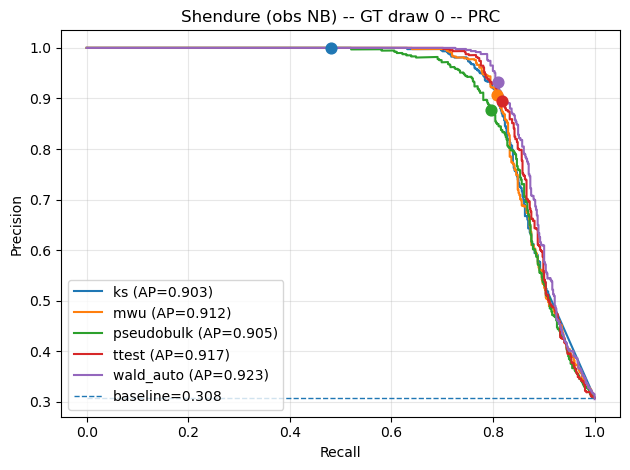

scMPRAforge: INFO: Dropped 15 or 0.7% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 6 or 0.3% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 16 or 0.8% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 13 or 0.6% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 14 or 0.7% of tests with NA values for test:wald_auto, rep:4.


Called positive: 282 / 2060 (13.6893%)
Called positive: 574 / 2060 (27.8641%)
Called positive: 555 / 2060 (26.9417%)
Called positive: 597 / 2060 (28.9806%)
Called positive: 590 / 2046 (28.8368%)


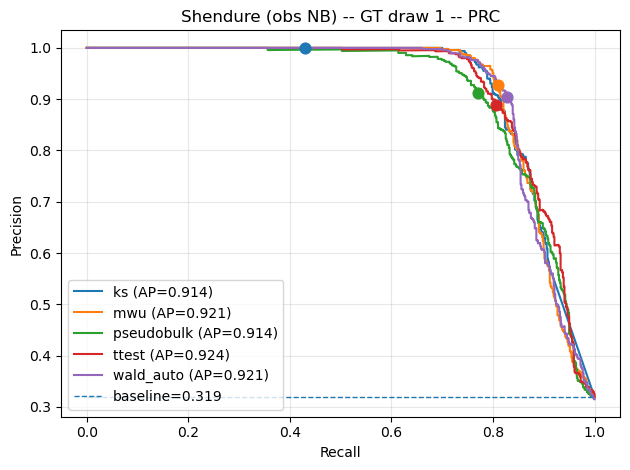

scMPRAforge: INFO: Dropped 15 or 0.7% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 16 or 0.8% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 14 or 0.7% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 15 or 0.7% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 12 or 0.6% of tests with NA values for test:wald_auto, rep:4.


Called positive: 298 / 2060 (14.4660%)
Called positive: 609 / 2060 (29.5631%)
Called positive: 563 / 2060 (27.3301%)
Called positive: 590 / 2060 (28.6408%)
Called positive: 577 / 2045 (28.2152%)


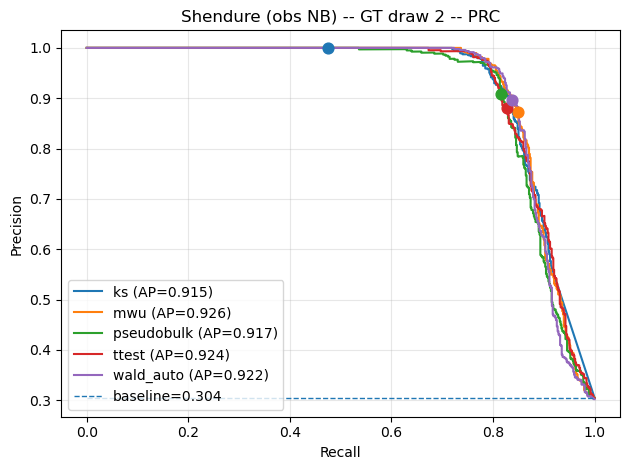

scMPRAforge: INFO: Dropped 11 or 0.5% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 14 or 0.7% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 15 or 0.7% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 15 or 0.7% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 15 or 0.7% of tests with NA values for test:wald_auto, rep:4.


Called positive: 283 / 2060 (13.7379%)
Called positive: 587 / 2060 (28.4951%)
Called positive: 581 / 2060 (28.2039%)
Called positive: 614 / 2060 (29.8058%)
Called positive: 600 / 2049 (29.2826%)


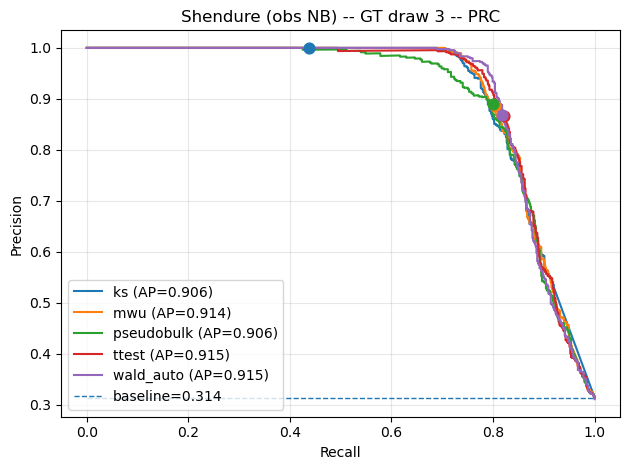

scMPRAforge: INFO: Dropped 10 or 0.5% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 13 or 0.6% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 11 or 0.5% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 10 or 0.5% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 6 or 0.3% of tests with NA values for test:wald_auto, rep:4.


Called positive: 288 / 2060 (13.9806%)
Called positive: 584 / 2060 (28.3495%)
Called positive: 576 / 2060 (27.9612%)
Called positive: 575 / 2060 (27.9126%)
Called positive: 582 / 2047 (28.4319%)


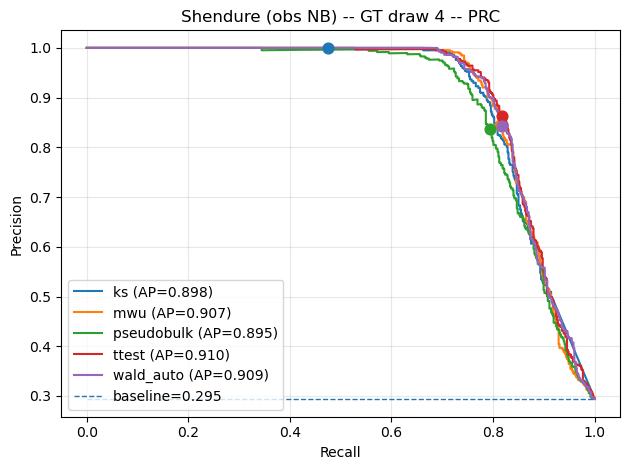

scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:ks, rep:1.


scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:ks, rep:2.



Cohen (obsingle NB) -- Median-replicate PRC curves


scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:ks, rep:4.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:mwu, rep:1.


...

scMPRAforge: INFO: Dropped 8 or 1.7% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 7 or 1.5% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 2 or 0.4% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 8 or 1.7% of tests with NA values for test:wald_auto, rep:4.


Called positive: 83 / 456 (18.2018%)
Called positive: 109 / 460 (23.6957%)
Called positive: 75 / 459 (16.3399%)
Called positive: 116 / 456 (25.4386%)
Called positive: 167 / 452 (36.9469%)


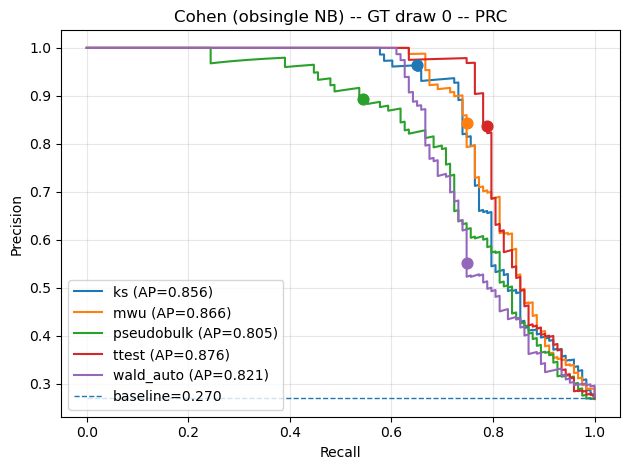

scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:ks, rep:1.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:ks, rep:3.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:ks, rep:4.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:mwu, rep:1.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:mwu, rep:3.


...

scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 6 or 1.3% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 7 or 1.5% of tests with NA values for test:wald_auto, rep:4.


Called positive: 83 / 460 (18.0435%)
Called positive: 107 / 460 (23.2609%)
Called positive: 82 / 457 (17.9431%)
Called positive: 109 / 458 (23.7991%)
Called positive: 220 / 460 (47.8261%)


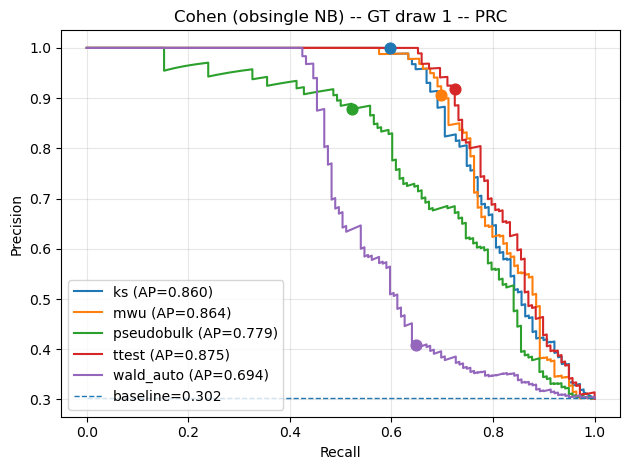

scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:ks, rep:3.


scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:ks, rep:4.


scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:mwu, rep:3.


scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:mwu, rep:4.


scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:pseudobulk, rep:0.


...

scMPRAforge: INFO: Dropped 5 or 1.1% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 5 or 1.1% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 5 or 1.1% of tests with NA values for test:wald_auto, rep:4.


Called positive: 93 / 459 (20.2614%)
Called positive: 115 / 459 (25.0545%)
Called positive: 92 / 456 (20.1754%)
Called positive: 125 / 459 (27.2331%)
Called positive: 123 / 454 (27.0925%)


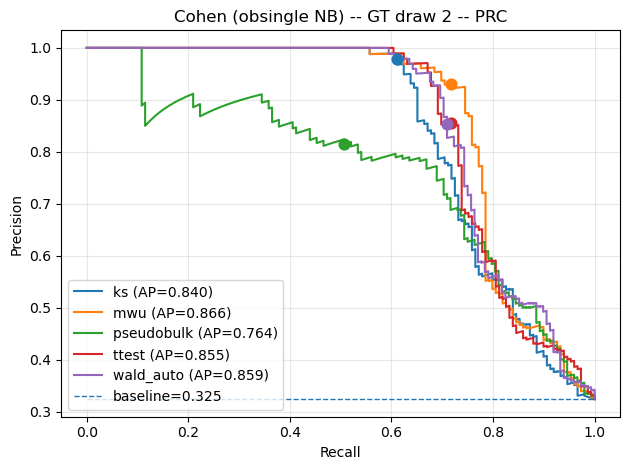

scMPRAforge: INFO: Dropped 2 or 0.4% of tests with NA values for test:pseudobulk, rep:3.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:pseudobulk, rep:4.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:ttest, rep:4.


scMPRAforge: INFO: Dropped 2 or 0.4% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 2 or 0.4% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:wald_auto, rep:4.


Called positive: 84 / 459 (18.3007%)
Called positive: 106 / 459 (23.0937%)
Called positive: 65 / 457 (14.2232%)
Called positive: 106 / 459 (23.0937%)
Called positive: 159 / 457 (34.7921%)


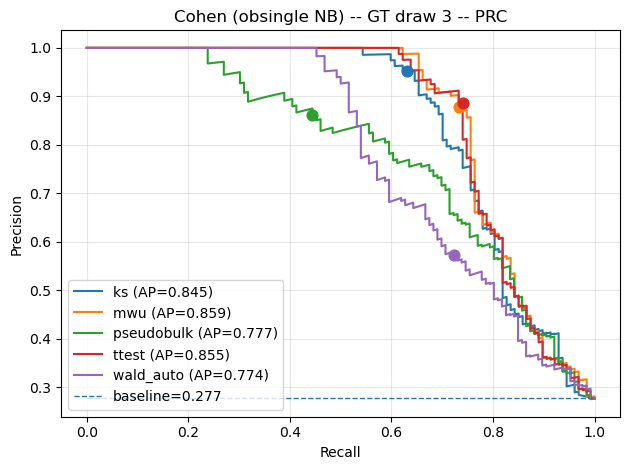

scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:ks, rep:1.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:ks, rep:4.


scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:mwu, rep:1.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:mwu, rep:4.


scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:pseudobulk, rep:0.


...

scMPRAforge: INFO: Dropped 9 or 2.0% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 2 or 0.4% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:wald_auto, rep:4.


Called positive: 87 / 459 (18.9542%)
Called positive: 108 / 459 (23.5294%)
Called positive: 78 / 460 (16.9565%)
Called positive: 119 / 460 (25.8696%)
Called positive: 275 / 457 (60.1751%)


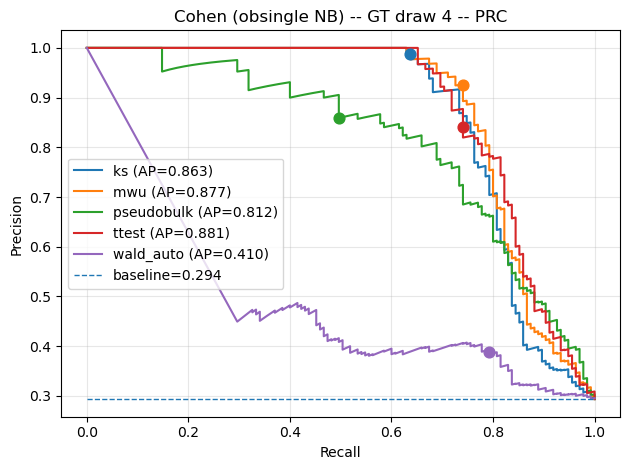

scMPRAforge: INFO: Dropped 5 or 0.2% of tests with NA values for test:ks, rep:0.



Seelig (MOIB NB) -- Median-replicate PRC curves


scMPRAforge: INFO: Dropped 5 or 0.2% of tests with NA values for test:ks, rep:1.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:2.


scMPRAforge: INFO: Dropped 5 or 0.2% of tests with NA values for test:ks, rep:3.


...

scMPRAforge: INFO: Dropped 5 or 0.2% of tests with NA values for test:ttest, rep:2.


scMPRAforge: INFO: Dropped 5 or 0.2% of tests with NA values for test:ttest, rep:3.


scMPRAforge: INFO: Dropped 6 or 0.2% of tests with NA values for test:ttest, rep:4.


scMPRAforge: INFO: Dropped 2 or 0.1% of tests with NA values for test:wald_auto, rep:0.


Called positive: 385 / 2681 (14.3603%)
Called positive: 497 / 2681 (18.5379%)
Called positive: 602 / 2681 (22.4543%)
Called positive: 2369 / 2686 (88.1981%)


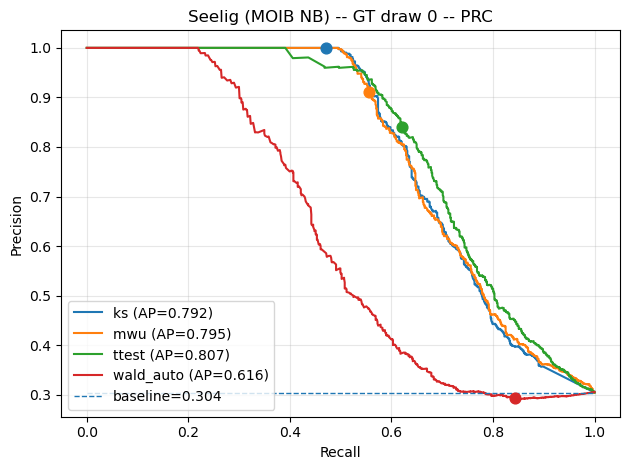

scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:0.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:1.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:2.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:3.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:4.


...

scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ttest, rep:1.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ttest, rep:2.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ttest, rep:3.


scMPRAforge: INFO: Dropped 5 or 0.2% of tests with NA values for test:ttest, rep:4.


Called positive: 378 / 2682 (14.0940%)
Called positive: 499 / 2682 (18.6055%)
Called positive: 621 / 2681 (23.1630%)
Called positive: 2452 / 2686 (91.2882%)


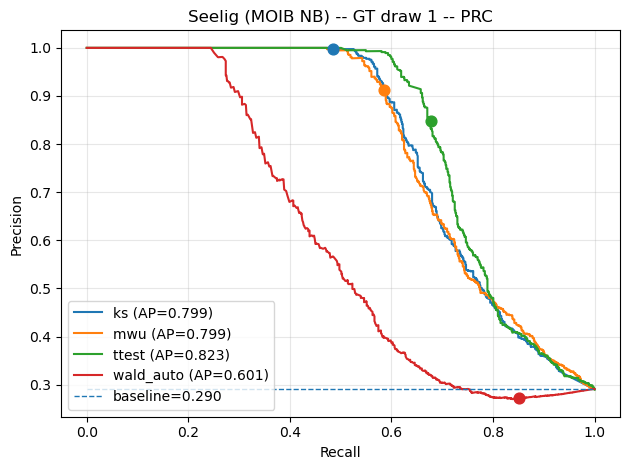

scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:0.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:1.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:2.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:3.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:4.


...

scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ttest, rep:1.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ttest, rep:2.


scMPRAforge: INFO: Dropped 6 or 0.2% of tests with NA values for test:ttest, rep:3.


scMPRAforge: INFO: Dropped 5 or 0.2% of tests with NA values for test:ttest, rep:4.


Called positive: 341 / 2682 (12.7144%)
Called positive: 376 / 2682 (14.0194%)
Called positive: 415 / 2680 (15.4851%)
Called positive: 2386 / 2686 (88.8310%)


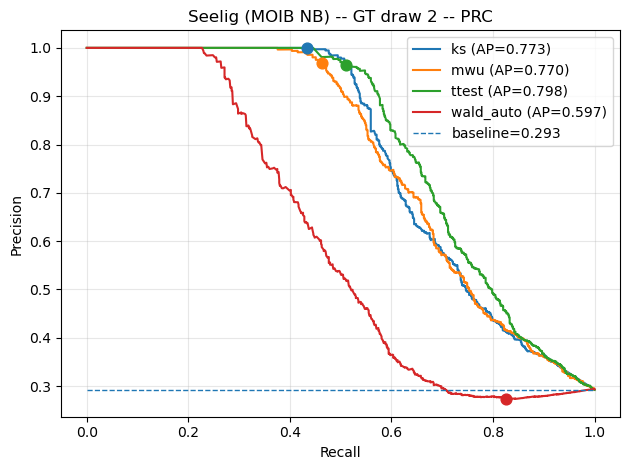

scMPRAforge: INFO: Dropped 3 or 0.1% of tests with NA values for test:ks, rep:0.


scMPRAforge: INFO: Dropped 3 or 0.1% of tests with NA values for test:ks, rep:1.


scMPRAforge: INFO: Dropped 3 or 0.1% of tests with NA values for test:ks, rep:2.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:3.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:4.


...

scMPRAforge: INFO: Dropped 3 or 0.1% of tests with NA values for test:ttest, rep:1.


scMPRAforge: INFO: Dropped 3 or 0.1% of tests with NA values for test:ttest, rep:2.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ttest, rep:3.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ttest, rep:4.


Called positive: 374 / 2683 (13.9396%)
Called positive: 594 / 2682 (22.1477%)
Called positive: 573 / 2682 (21.3647%)
Called positive: 2389 / 2686 (88.9427%)


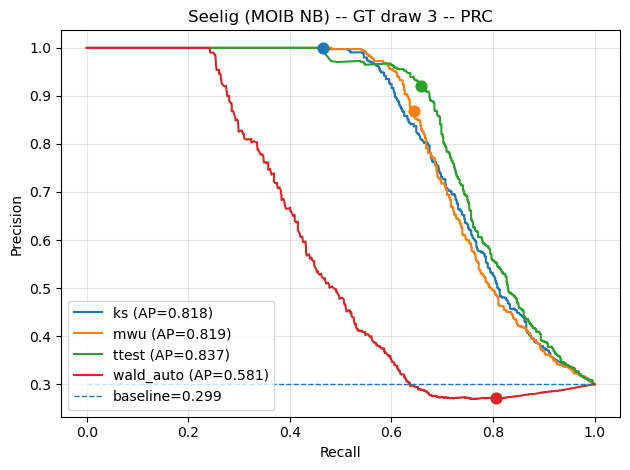

scMPRAforge: INFO: Dropped 5 or 0.2% of tests with NA values for test:ks, rep:0.


scMPRAforge: INFO: Dropped 5 or 0.2% of tests with NA values for test:ks, rep:1.


scMPRAforge: INFO: Dropped 6 or 0.2% of tests with NA values for test:ks, rep:2.


scMPRAforge: INFO: Dropped 6 or 0.2% of tests with NA values for test:ks, rep:3.


scMPRAforge: INFO: Dropped 6 or 0.2% of tests with NA values for test:ks, rep:4.


...

scMPRAforge: INFO: Dropped 5 or 0.2% of tests with NA values for test:ttest, rep:1.


scMPRAforge: INFO: Dropped 7 or 0.3% of tests with NA values for test:ttest, rep:2.


scMPRAforge: INFO: Dropped 6 or 0.2% of tests with NA values for test:ttest, rep:3.


scMPRAforge: INFO: Dropped 7 or 0.3% of tests with NA values for test:ttest, rep:4.


Called positive: 371 / 2681 (13.8381%)
Called positive: 613 / 2680 (22.8731%)
Called positive: 594 / 2679 (22.1725%)
Called positive: 2344 / 2686 (87.2673%)


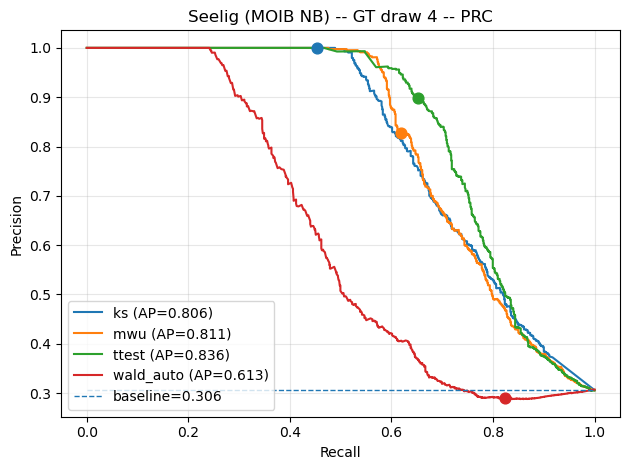

In [5]:
for label, gt_sims in sims.items():
    print(f"\n{'='*60}")
    print(f"{label} -- Median-replicate PRC curves")
    print(f"{'='*60}")
    for gt_idx, sim in enumerate(gt_sims):
        try:
            sim.median_performance_curve(
                HYPOTHESIS_SET, "PRC", include_alpha=True
            )
            plt.title(f"{label} -- GT draw {gt_idx} -- PRC")
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"  GT {gt_idx}: {e}")

## Median-replicate ROC curves


Shendure (obs NB) -- Median-replicate ROC curves


scMPRAforge: INFO: Dropped 16 or 0.8% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 10 or 0.5% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 10 or 0.5% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 18 or 0.9% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 6 or 0.3% of tests with NA values for test:wald_auto, rep:4.


Called positive: 305 / 2060 (14.8058%)
Called positive: 565 / 2060 (27.4272%)
Called positive: 576 / 2060 (27.9612%)
Called positive: 580 / 2060 (28.1553%)
Called positive: 542 / 2044 (26.5166%)


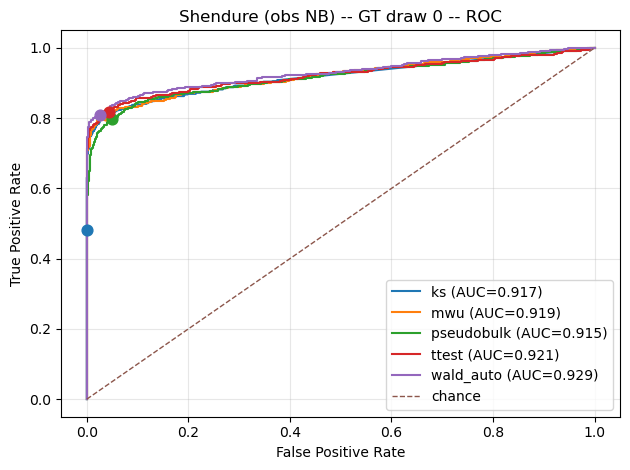

scMPRAforge: INFO: Dropped 15 or 0.7% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 6 or 0.3% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 16 or 0.8% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 13 or 0.6% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 14 or 0.7% of tests with NA values for test:wald_auto, rep:4.


Called positive: 282 / 2060 (13.6893%)
Called positive: 613 / 2060 (29.7573%)
Called positive: 555 / 2060 (26.9417%)
Called positive: 593 / 2060 (28.7864%)
Called positive: 568 / 2045 (27.7751%)


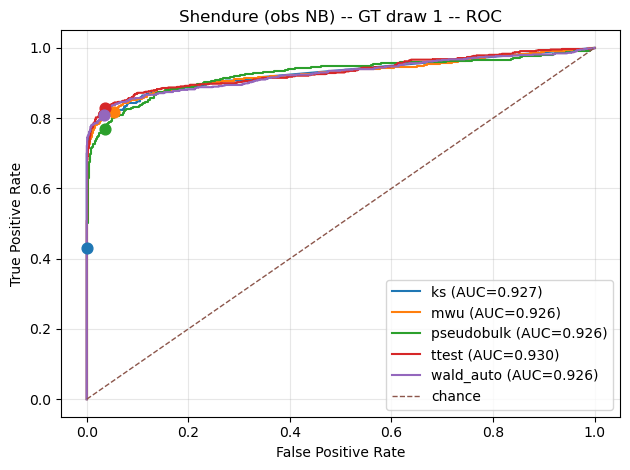

scMPRAforge: INFO: Dropped 15 or 0.7% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 16 or 0.8% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 14 or 0.7% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 15 or 0.7% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 12 or 0.6% of tests with NA values for test:wald_auto, rep:4.


Called positive: 298 / 2060 (14.4660%)
Called positive: 609 / 2060 (29.5631%)
Called positive: 568 / 2060 (27.5728%)
Called positive: 590 / 2060 (28.6408%)
Called positive: 562 / 2048 (27.4414%)


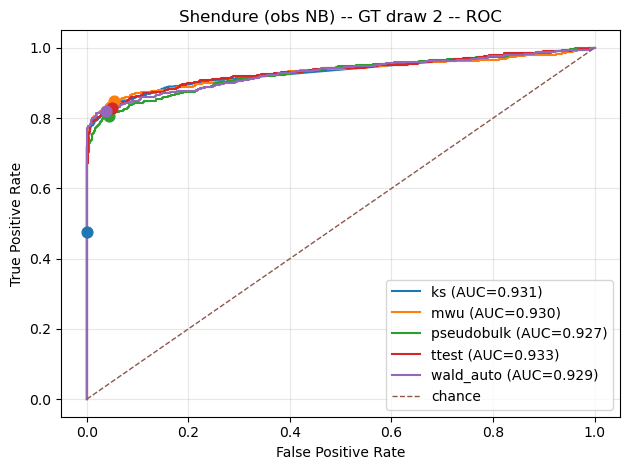

scMPRAforge: INFO: Dropped 11 or 0.5% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 14 or 0.7% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 15 or 0.7% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 15 or 0.7% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 15 or 0.7% of tests with NA values for test:wald_auto, rep:4.


Called positive: 310 / 2060 (15.0485%)
Called positive: 622 / 2060 (30.1942%)
Called positive: 581 / 2060 (28.2039%)
Called positive: 614 / 2060 (29.8058%)
Called positive: 595 / 2045 (29.0954%)


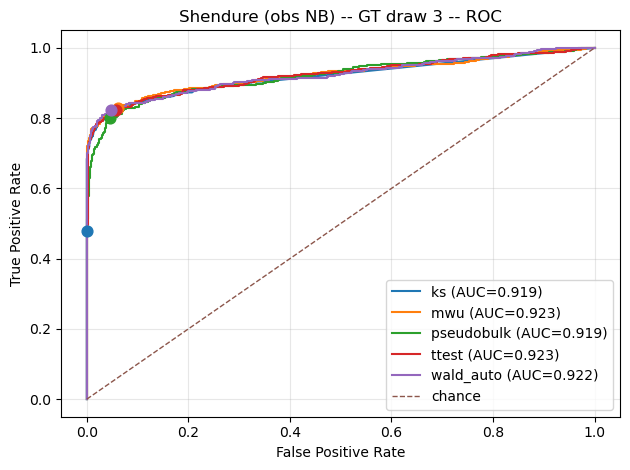

scMPRAforge: INFO: Dropped 10 or 0.5% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 13 or 0.6% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 11 or 0.5% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 10 or 0.5% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 6 or 0.3% of tests with NA values for test:wald_auto, rep:4.


Called positive: 288 / 2060 (13.9806%)
Called positive: 584 / 2060 (28.3495%)
Called positive: 560 / 2060 (27.1845%)
Called positive: 575 / 2060 (27.9126%)
Called positive: 582 / 2047 (28.4319%)


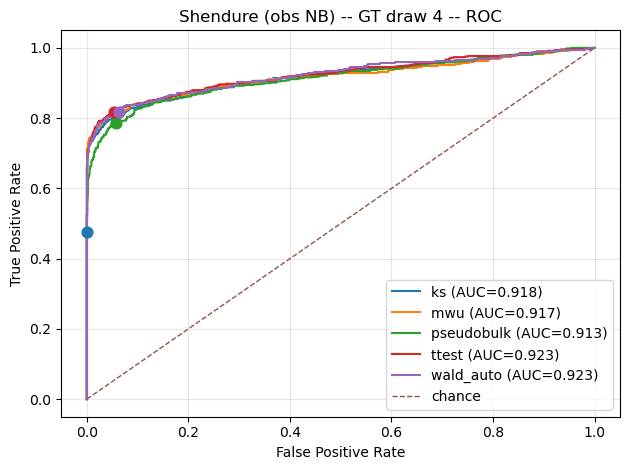

scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:ks, rep:1.


scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:ks, rep:2.



Cohen (obsingle NB) -- Median-replicate ROC curves


scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:ks, rep:4.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:mwu, rep:1.


...

scMPRAforge: INFO: Dropped 8 or 1.7% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 7 or 1.5% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 2 or 0.4% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 8 or 1.7% of tests with NA values for test:wald_auto, rep:4.


Called positive: 83 / 456 (18.2018%)
Called positive: 109 / 460 (23.6957%)
Called positive: 64 / 455 (14.0659%)
Called positive: 116 / 456 (25.4386%)
Called positive: 167 / 452 (36.9469%)


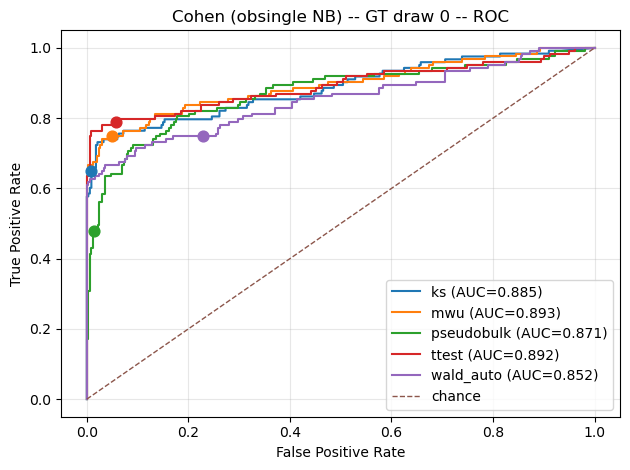

scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:ks, rep:1.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:ks, rep:3.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:ks, rep:4.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:mwu, rep:1.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:mwu, rep:3.


...

scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 6 or 1.3% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 7 or 1.5% of tests with NA values for test:wald_auto, rep:4.


Called positive: 83 / 460 (18.0435%)
Called positive: 107 / 460 (23.2609%)
Called positive: 82 / 457 (17.9431%)
Called positive: 115 / 457 (25.1641%)
Called positive: 220 / 460 (47.8261%)


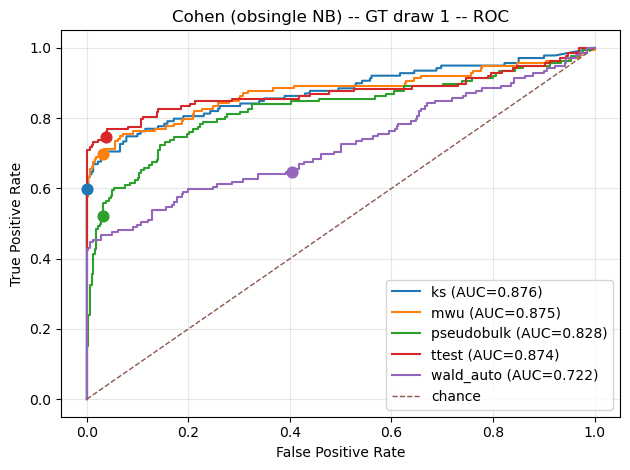

scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:ks, rep:3.


scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:ks, rep:4.


scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:mwu, rep:3.


scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:mwu, rep:4.


scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:pseudobulk, rep:0.


...

scMPRAforge: INFO: Dropped 5 or 1.1% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 5 or 1.1% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 5 or 1.1% of tests with NA values for test:wald_auto, rep:4.


Called positive: 87 / 455 (19.1209%)
Called positive: 115 / 459 (25.0545%)
Called positive: 92 / 456 (20.1754%)
Called positive: 125 / 459 (27.2331%)
Called positive: 123 / 454 (27.0925%)


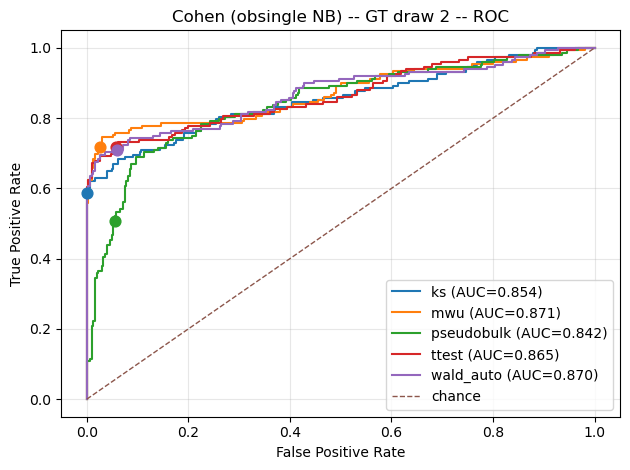

scMPRAforge: INFO: Dropped 2 or 0.4% of tests with NA values for test:pseudobulk, rep:3.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:pseudobulk, rep:4.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:ttest, rep:4.


scMPRAforge: INFO: Dropped 2 or 0.4% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 2 or 0.4% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:wald_auto, rep:4.


Called positive: 84 / 459 (18.3007%)
Called positive: 106 / 459 (23.0937%)
Called positive: 65 / 457 (14.2232%)
Called positive: 106 / 459 (23.0937%)
Called positive: 159 / 457 (34.7921%)


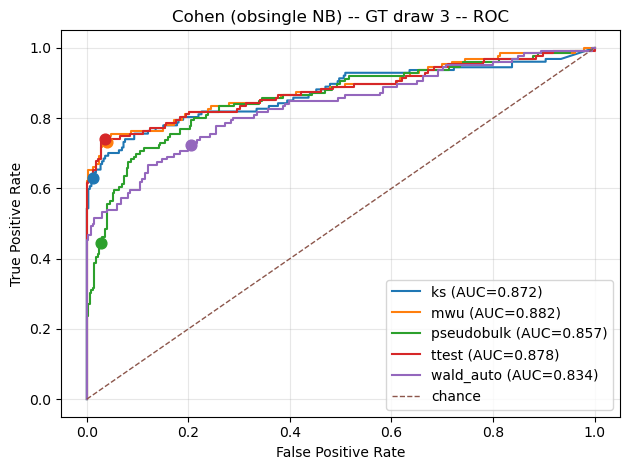

scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:ks, rep:1.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:ks, rep:4.


scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:mwu, rep:1.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:mwu, rep:4.


scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:pseudobulk, rep:0.


...

scMPRAforge: INFO: Dropped 9 or 2.0% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 2 or 0.4% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:wald_auto, rep:4.


Called positive: 87 / 459 (18.9542%)
Called positive: 108 / 459 (23.5294%)
Called positive: 94 / 457 (20.5689%)
Called positive: 119 / 460 (25.8696%)
Called positive: 357 / 459 (77.7778%)


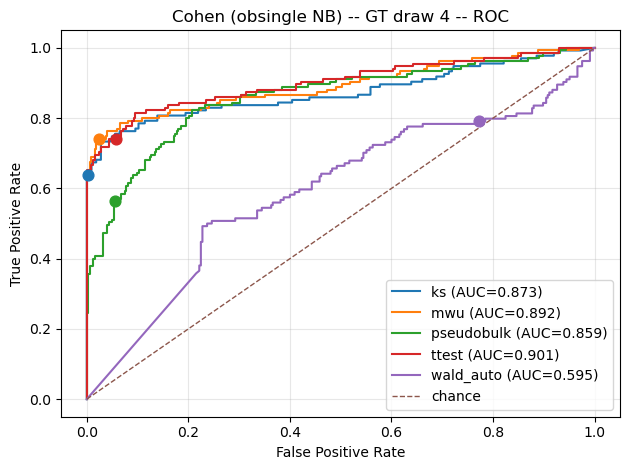

scMPRAforge: INFO: Dropped 5 or 0.2% of tests with NA values for test:ks, rep:0.



Seelig (MOIB NB) -- Median-replicate ROC curves


scMPRAforge: INFO: Dropped 5 or 0.2% of tests with NA values for test:ks, rep:1.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:2.


scMPRAforge: INFO: Dropped 5 or 0.2% of tests with NA values for test:ks, rep:3.


...

scMPRAforge: INFO: Dropped 5 or 0.2% of tests with NA values for test:ttest, rep:2.


scMPRAforge: INFO: Dropped 5 or 0.2% of tests with NA values for test:ttest, rep:3.


scMPRAforge: INFO: Dropped 6 or 0.2% of tests with NA values for test:ttest, rep:4.


scMPRAforge: INFO: Dropped 2 or 0.1% of tests with NA values for test:wald_auto, rep:0.


Called positive: 385 / 2681 (14.3603%)
Called positive: 536 / 2681 (19.9925%)
Called positive: 602 / 2681 (22.4543%)
Called positive: 2369 / 2686 (88.1981%)


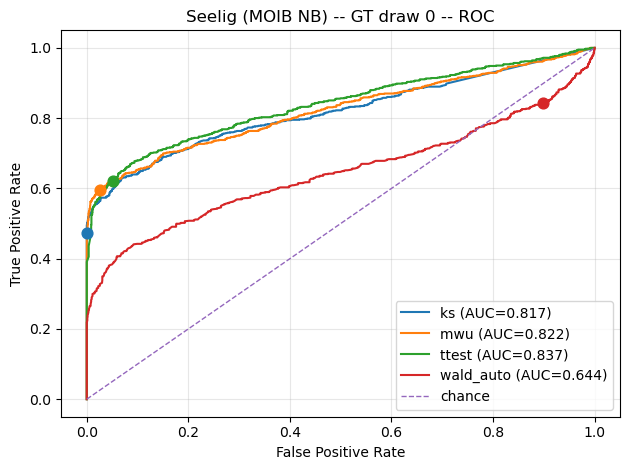

scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:0.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:1.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:2.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:3.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:4.


...

scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ttest, rep:1.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ttest, rep:2.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ttest, rep:3.


scMPRAforge: INFO: Dropped 5 or 0.2% of tests with NA values for test:ttest, rep:4.


Called positive: 378 / 2682 (14.0940%)
Called positive: 499 / 2682 (18.6055%)
Called positive: 621 / 2681 (23.1630%)
Called positive: 2469 / 2686 (91.9211%)


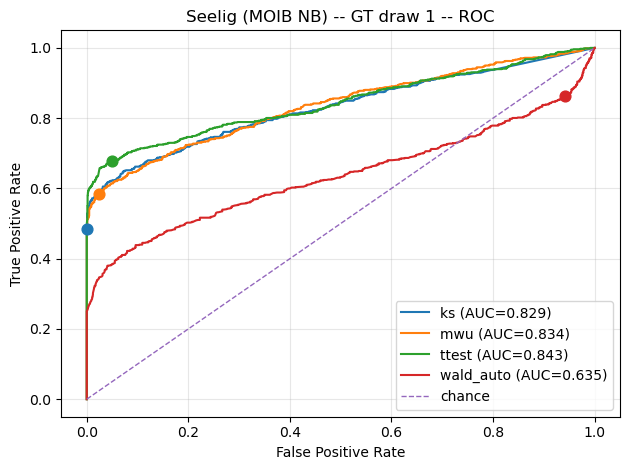

scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:0.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:1.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:2.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:3.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:4.


...

scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ttest, rep:1.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ttest, rep:2.


scMPRAforge: INFO: Dropped 6 or 0.2% of tests with NA values for test:ttest, rep:3.


scMPRAforge: INFO: Dropped 5 or 0.2% of tests with NA values for test:ttest, rep:4.


Called positive: 341 / 2682 (12.7144%)
Called positive: 376 / 2682 (14.0194%)
Called positive: 415 / 2680 (15.4851%)
Called positive: 2386 / 2686 (88.8310%)


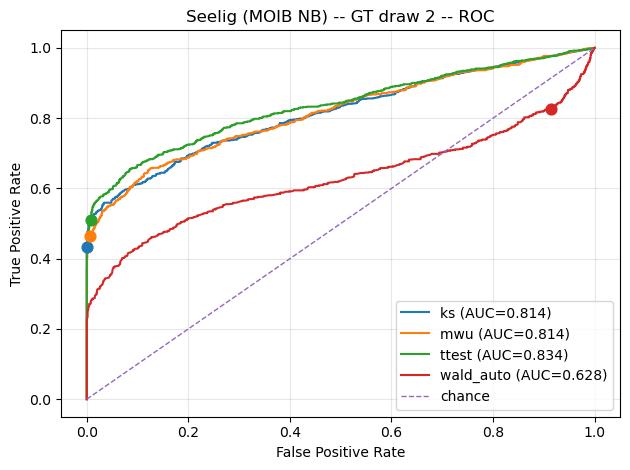

scMPRAforge: INFO: Dropped 3 or 0.1% of tests with NA values for test:ks, rep:0.


scMPRAforge: INFO: Dropped 3 or 0.1% of tests with NA values for test:ks, rep:1.


scMPRAforge: INFO: Dropped 3 or 0.1% of tests with NA values for test:ks, rep:2.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:3.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:4.


...

scMPRAforge: INFO: Dropped 3 or 0.1% of tests with NA values for test:ttest, rep:1.


scMPRAforge: INFO: Dropped 3 or 0.1% of tests with NA values for test:ttest, rep:2.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ttest, rep:3.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ttest, rep:4.


Called positive: 374 / 2683 (13.9396%)
Called positive: 522 / 2682 (19.4631%)
Called positive: 599 / 2682 (22.3341%)
Called positive: 2389 / 2686 (88.9427%)


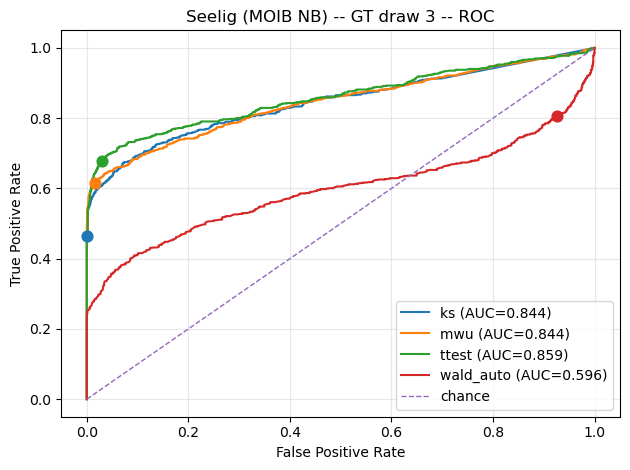

scMPRAforge: INFO: Dropped 5 or 0.2% of tests with NA values for test:ks, rep:0.


scMPRAforge: INFO: Dropped 5 or 0.2% of tests with NA values for test:ks, rep:1.


scMPRAforge: INFO: Dropped 6 or 0.2% of tests with NA values for test:ks, rep:2.


scMPRAforge: INFO: Dropped 6 or 0.2% of tests with NA values for test:ks, rep:3.


scMPRAforge: INFO: Dropped 6 or 0.2% of tests with NA values for test:ks, rep:4.


...

scMPRAforge: INFO: Dropped 5 or 0.2% of tests with NA values for test:ttest, rep:1.


scMPRAforge: INFO: Dropped 7 or 0.3% of tests with NA values for test:ttest, rep:2.


scMPRAforge: INFO: Dropped 6 or 0.2% of tests with NA values for test:ttest, rep:3.


scMPRAforge: INFO: Dropped 7 or 0.3% of tests with NA values for test:ttest, rep:4.


Called positive: 398 / 2680 (14.8507%)
Called positive: 519 / 2680 (19.3657%)
Called positive: 605 / 2679 (22.5831%)
Called positive: 2404 / 2686 (89.5011%)


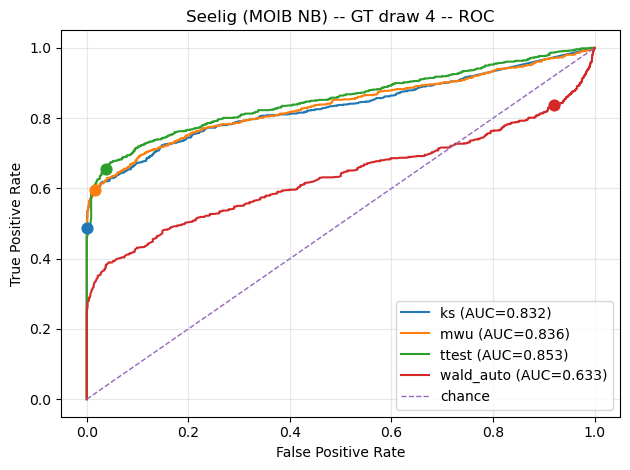

In [6]:
for label, gt_sims in sims.items():
    print(f"\n{'='*60}")
    print(f"{label} -- Median-replicate ROC curves")
    print(f"{'='*60}")
    for gt_idx, sim in enumerate(gt_sims):
        try:
            sim.median_performance_curve(
                HYPOTHESIS_SET, "ROC", include_alpha=True
            )
            plt.title(f"{label} -- GT draw {gt_idx} -- ROC")
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"  GT {gt_idx}: {e}")

## Performance barcharts (AUROC and AUPRC)

One barchart per GT draw showing test comparison.


Shendure (obs NB) -- Performance barcharts


scMPRAforge: INFO: Dropped 16 or 0.8% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 10 or 0.5% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 10 or 0.5% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 18 or 0.9% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 6 or 0.3% of tests with NA values for test:wald_auto, rep:4.


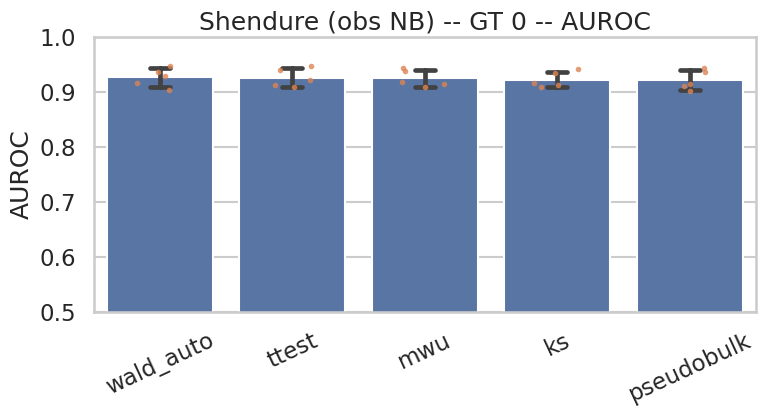

scMPRAforge: INFO: Dropped 16 or 0.8% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 10 or 0.5% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 10 or 0.5% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 18 or 0.9% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 6 or 0.3% of tests with NA values for test:wald_auto, rep:4.


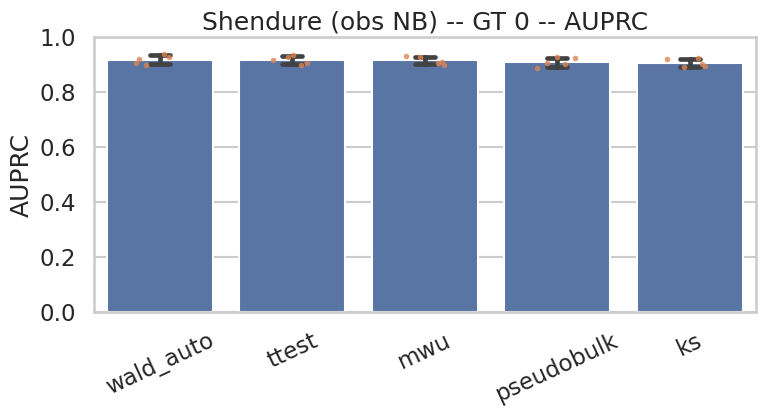

scMPRAforge: INFO: Dropped 15 or 0.7% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 6 or 0.3% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 16 or 0.8% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 13 or 0.6% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 14 or 0.7% of tests with NA values for test:wald_auto, rep:4.


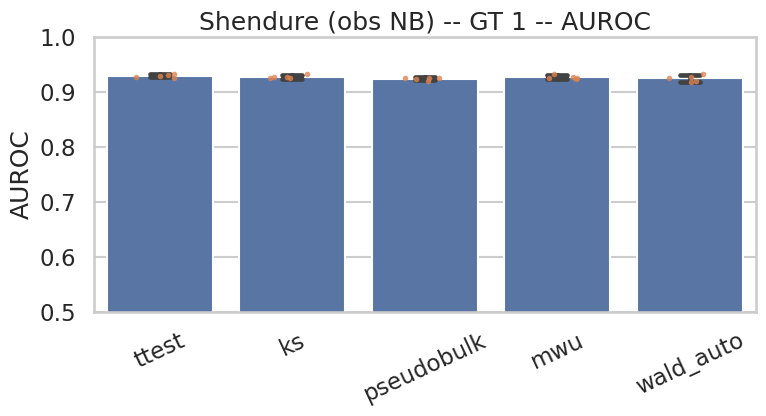

scMPRAforge: INFO: Dropped 15 or 0.7% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 6 or 0.3% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 16 or 0.8% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 13 or 0.6% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 14 or 0.7% of tests with NA values for test:wald_auto, rep:4.


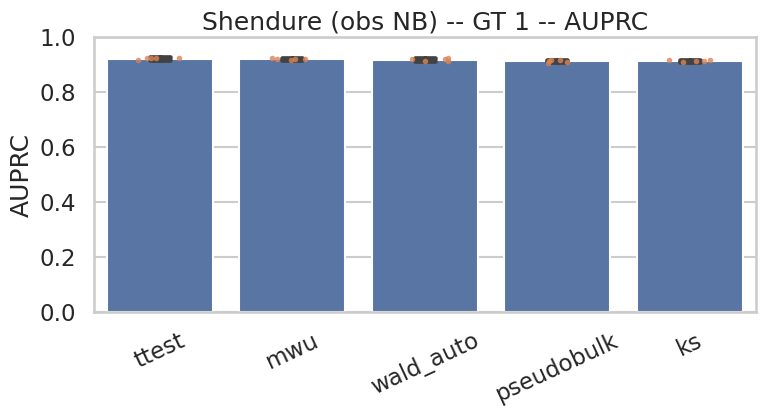

scMPRAforge: INFO: Dropped 15 or 0.7% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 16 or 0.8% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 14 or 0.7% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 15 or 0.7% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 12 or 0.6% of tests with NA values for test:wald_auto, rep:4.


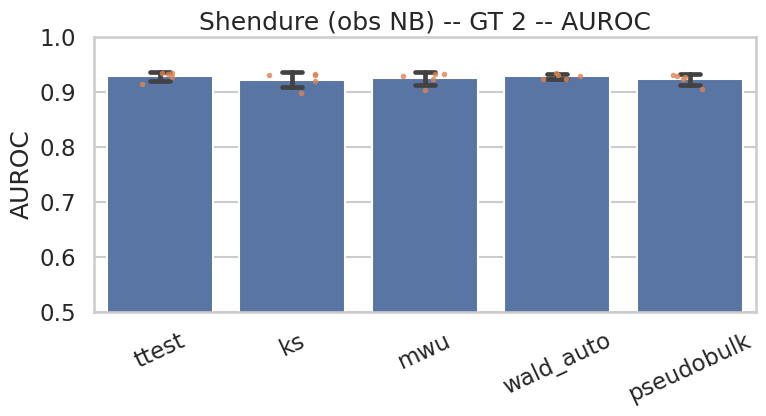

scMPRAforge: INFO: Dropped 15 or 0.7% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 16 or 0.8% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 14 or 0.7% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 15 or 0.7% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 12 or 0.6% of tests with NA values for test:wald_auto, rep:4.


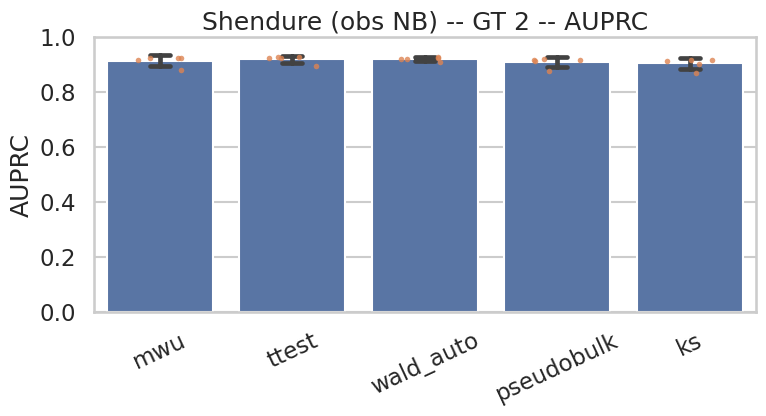

scMPRAforge: INFO: Dropped 11 or 0.5% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 14 or 0.7% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 15 or 0.7% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 15 or 0.7% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 15 or 0.7% of tests with NA values for test:wald_auto, rep:4.


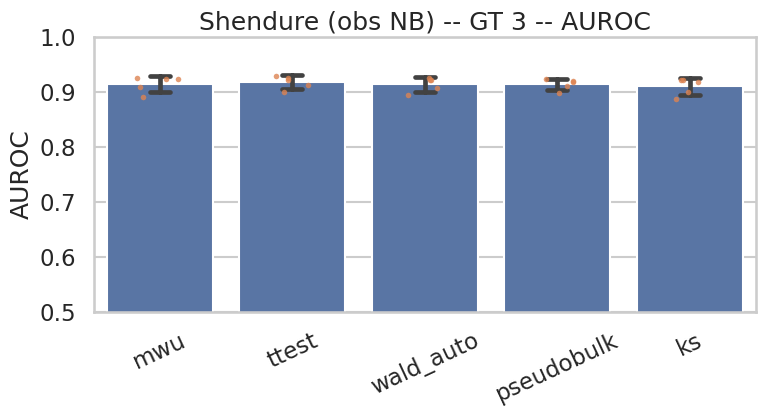

scMPRAforge: INFO: Dropped 11 or 0.5% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 14 or 0.7% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 15 or 0.7% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 15 or 0.7% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 15 or 0.7% of tests with NA values for test:wald_auto, rep:4.


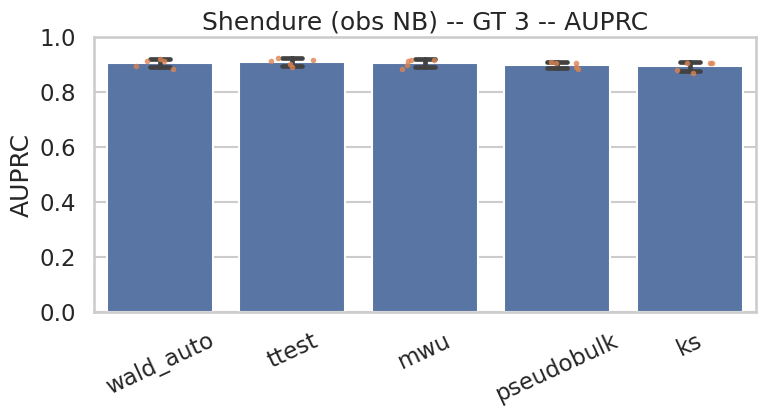

scMPRAforge: INFO: Dropped 10 or 0.5% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 13 or 0.6% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 11 or 0.5% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 10 or 0.5% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 6 or 0.3% of tests with NA values for test:wald_auto, rep:4.


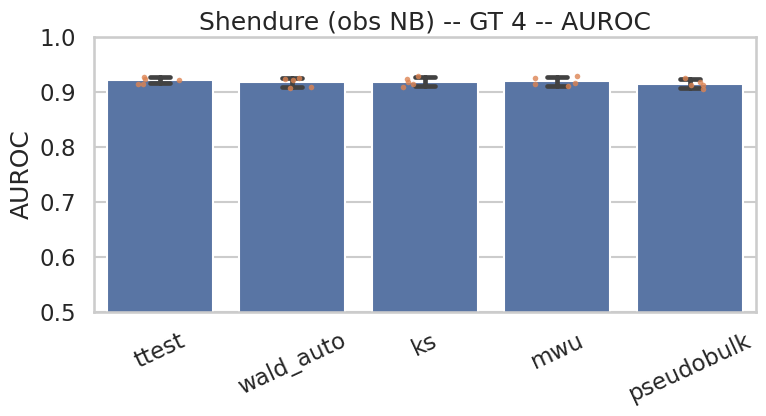

scMPRAforge: INFO: Dropped 10 or 0.5% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 13 or 0.6% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 11 or 0.5% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 10 or 0.5% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 6 or 0.3% of tests with NA values for test:wald_auto, rep:4.


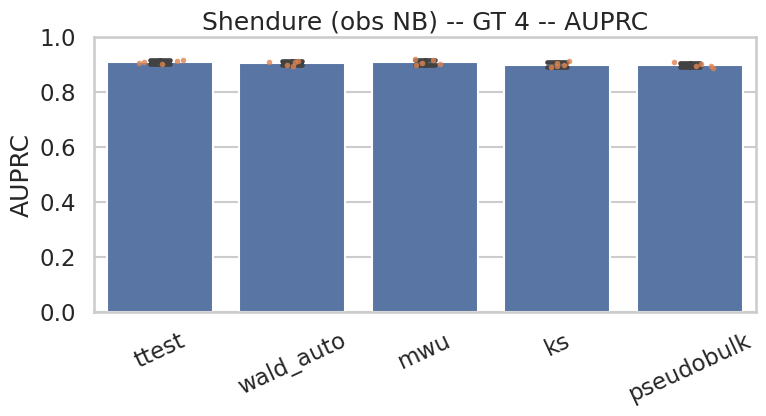

scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:ks, rep:1.


scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:ks, rep:2.


scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:ks, rep:4.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:mwu, rep:1.


scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:mwu, rep:2.


...

scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 8 or 1.7% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 7 or 1.5% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 2 or 0.4% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 8 or 1.7% of tests with NA values for test:wald_auto, rep:4.


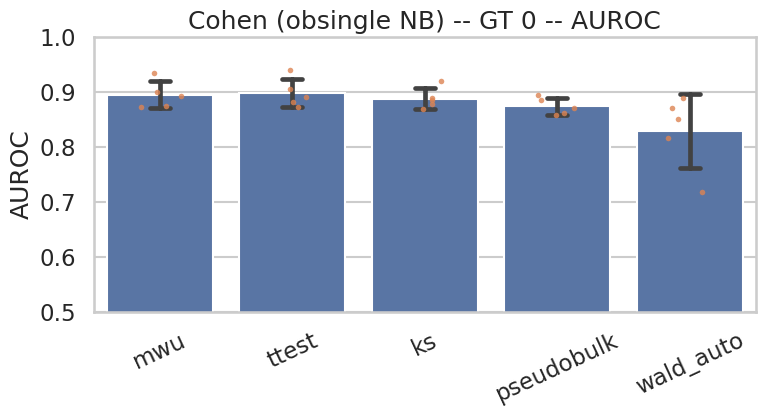

scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:ks, rep:1.


scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:ks, rep:2.


scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:ks, rep:4.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:mwu, rep:1.


scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:mwu, rep:2.


...

scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 8 or 1.7% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 7 or 1.5% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 2 or 0.4% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 8 or 1.7% of tests with NA values for test:wald_auto, rep:4.


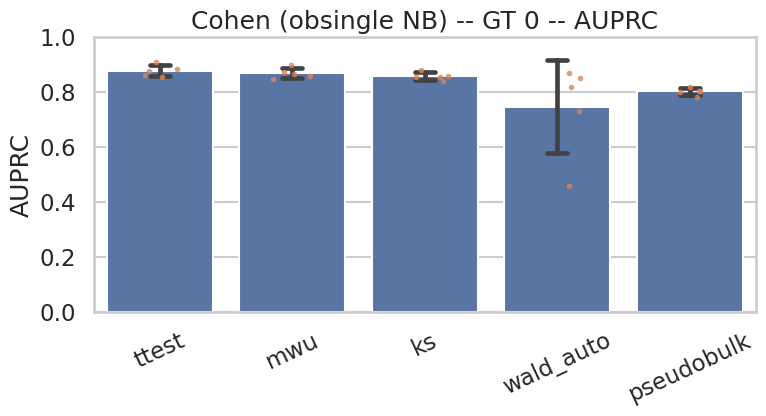

scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:ks, rep:1.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:ks, rep:3.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:ks, rep:4.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:mwu, rep:1.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:mwu, rep:3.


...

scMPRAforge: INFO: Dropped 6 or 1.3% of tests with NA values for test:ttest, rep:4.


scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 6 or 1.3% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 7 or 1.5% of tests with NA values for test:wald_auto, rep:4.


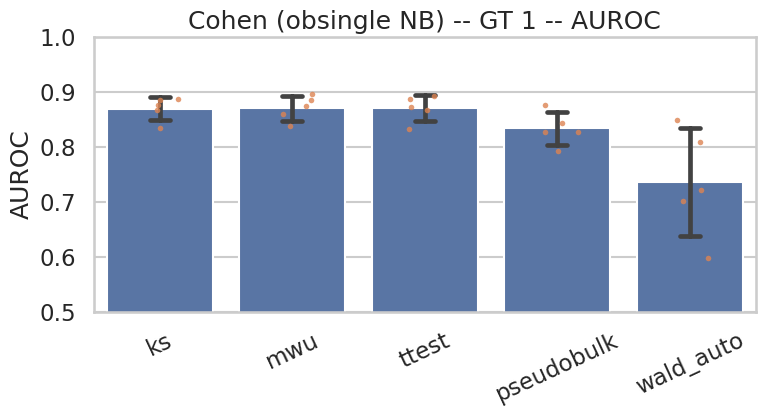

scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:ks, rep:1.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:ks, rep:3.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:ks, rep:4.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:mwu, rep:1.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:mwu, rep:3.


...

scMPRAforge: INFO: Dropped 6 or 1.3% of tests with NA values for test:ttest, rep:4.


scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 6 or 1.3% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 7 or 1.5% of tests with NA values for test:wald_auto, rep:4.


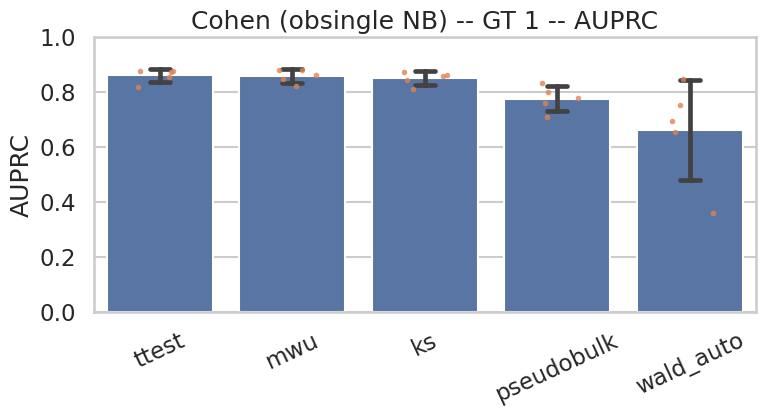

scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:ks, rep:3.


scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:ks, rep:4.


scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:mwu, rep:3.


scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:mwu, rep:4.


scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:pseudobulk, rep:0.


...

scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:ttest, rep:4.


scMPRAforge: INFO: Dropped 5 or 1.1% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 5 or 1.1% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 5 or 1.1% of tests with NA values for test:wald_auto, rep:4.


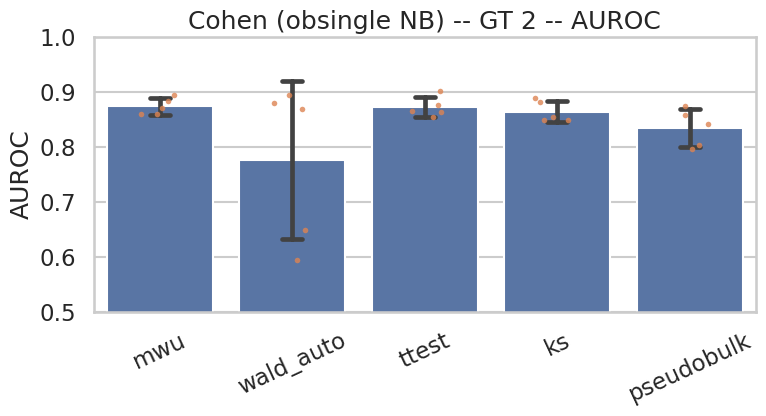

scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:ks, rep:3.


scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:ks, rep:4.


scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:mwu, rep:3.


scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:mwu, rep:4.


scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:pseudobulk, rep:0.


...

scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:ttest, rep:4.


scMPRAforge: INFO: Dropped 5 or 1.1% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 5 or 1.1% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 5 or 1.1% of tests with NA values for test:wald_auto, rep:4.


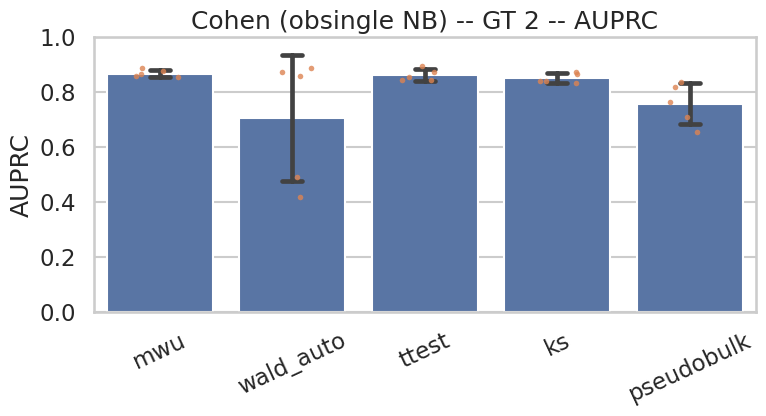

scMPRAforge: INFO: Dropped 2 or 0.4% of tests with NA values for test:pseudobulk, rep:3.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:pseudobulk, rep:4.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:ttest, rep:4.


scMPRAforge: INFO: Dropped 2 or 0.4% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 2 or 0.4% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:wald_auto, rep:4.


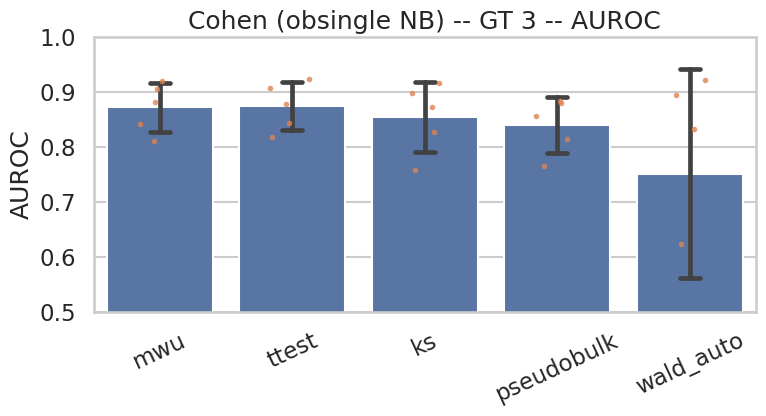

scMPRAforge: INFO: Dropped 2 or 0.4% of tests with NA values for test:pseudobulk, rep:3.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:pseudobulk, rep:4.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:ttest, rep:4.


scMPRAforge: INFO: Dropped 2 or 0.4% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 2 or 0.4% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:wald_auto, rep:4.


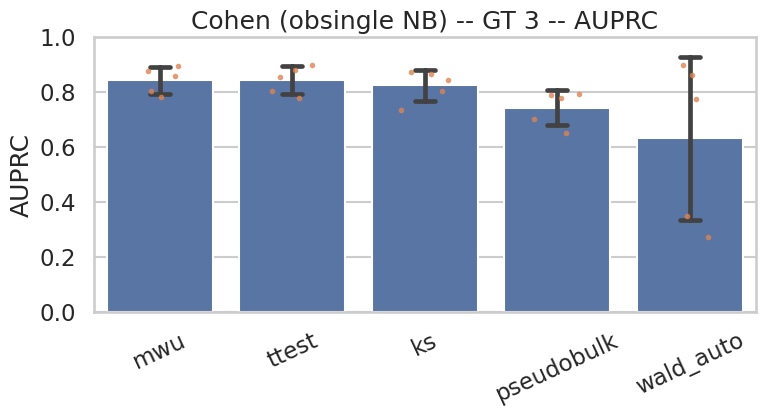

scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:ks, rep:1.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:ks, rep:4.


scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:mwu, rep:1.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:mwu, rep:4.


scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:pseudobulk, rep:0.


...

scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 9 or 2.0% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 2 or 0.4% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:wald_auto, rep:4.


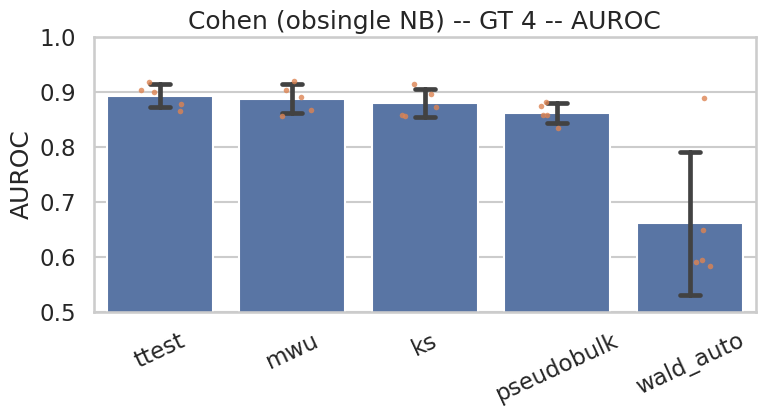

scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:ks, rep:1.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:ks, rep:4.


scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:mwu, rep:1.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:mwu, rep:4.


scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:pseudobulk, rep:0.


...

scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 9 or 2.0% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 2 or 0.4% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:wald_auto, rep:4.


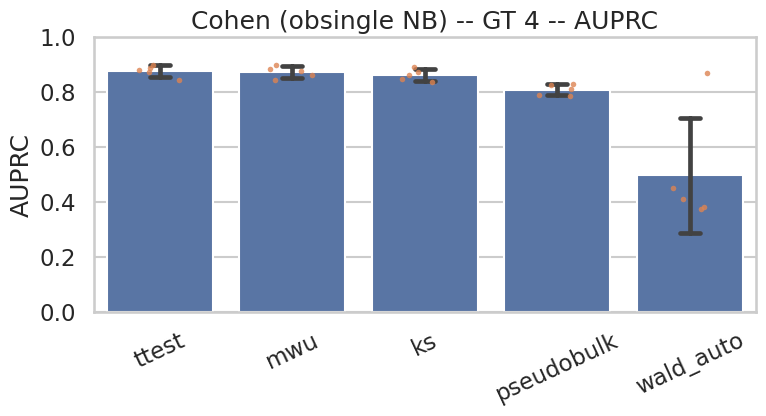

scMPRAforge: INFO: Dropped 5 or 0.2% of tests with NA values for test:ks, rep:0.


scMPRAforge: INFO: Dropped 5 or 0.2% of tests with NA values for test:ks, rep:1.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:2.


scMPRAforge: INFO: Dropped 5 or 0.2% of tests with NA values for test:ks, rep:3.


scMPRAforge: INFO: Dropped 5 or 0.2% of tests with NA values for test:ks, rep:4.


...

scMPRAforge: INFO: Dropped 5 or 0.2% of tests with NA values for test:ttest, rep:1.


scMPRAforge: INFO: Dropped 5 or 0.2% of tests with NA values for test:ttest, rep:2.


scMPRAforge: INFO: Dropped 5 or 0.2% of tests with NA values for test:ttest, rep:3.


scMPRAforge: INFO: Dropped 6 or 0.2% of tests with NA values for test:ttest, rep:4.


scMPRAforge: INFO: Dropped 2 or 0.1% of tests with NA values for test:wald_auto, rep:0.


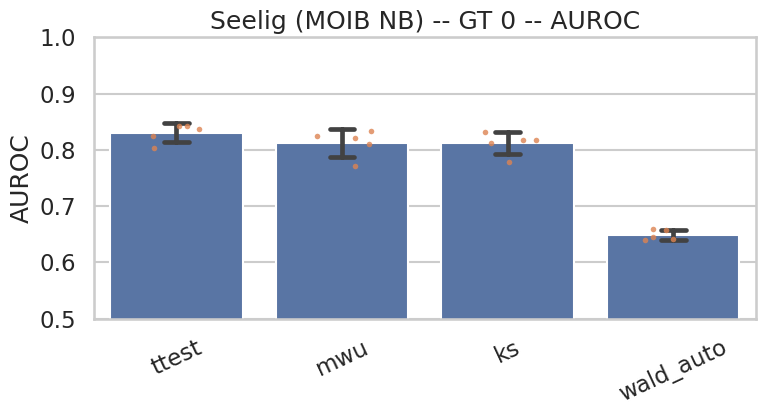

scMPRAforge: INFO: Dropped 5 or 0.2% of tests with NA values for test:ks, rep:0.


scMPRAforge: INFO: Dropped 5 or 0.2% of tests with NA values for test:ks, rep:1.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:2.


scMPRAforge: INFO: Dropped 5 or 0.2% of tests with NA values for test:ks, rep:3.


scMPRAforge: INFO: Dropped 5 or 0.2% of tests with NA values for test:ks, rep:4.


...

scMPRAforge: INFO: Dropped 5 or 0.2% of tests with NA values for test:ttest, rep:1.


scMPRAforge: INFO: Dropped 5 or 0.2% of tests with NA values for test:ttest, rep:2.


scMPRAforge: INFO: Dropped 5 or 0.2% of tests with NA values for test:ttest, rep:3.


scMPRAforge: INFO: Dropped 6 or 0.2% of tests with NA values for test:ttest, rep:4.


scMPRAforge: INFO: Dropped 2 or 0.1% of tests with NA values for test:wald_auto, rep:0.


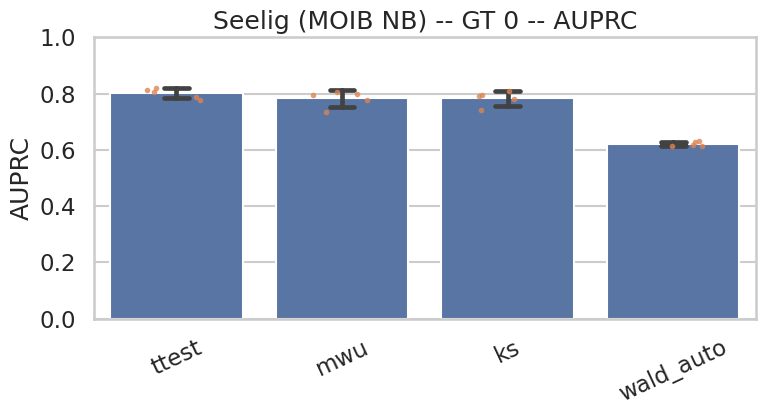

scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:0.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:1.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:2.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:3.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:4.


...

scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ttest, rep:0.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ttest, rep:1.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ttest, rep:2.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ttest, rep:3.


scMPRAforge: INFO: Dropped 5 or 0.2% of tests with NA values for test:ttest, rep:4.


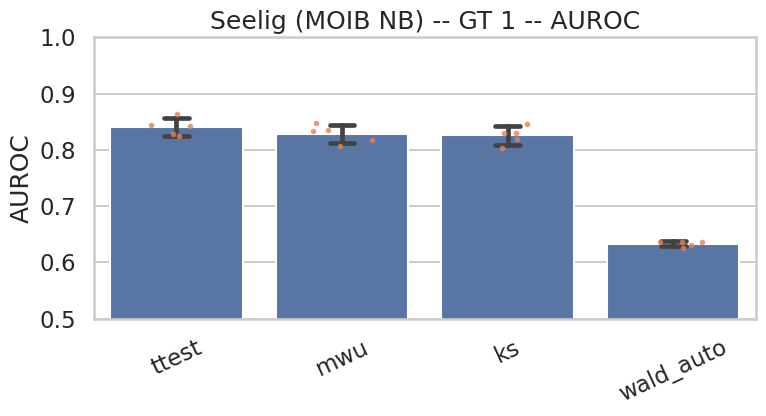

scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:0.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:1.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:2.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:3.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:4.


...

scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ttest, rep:0.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ttest, rep:1.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ttest, rep:2.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ttest, rep:3.


scMPRAforge: INFO: Dropped 5 or 0.2% of tests with NA values for test:ttest, rep:4.


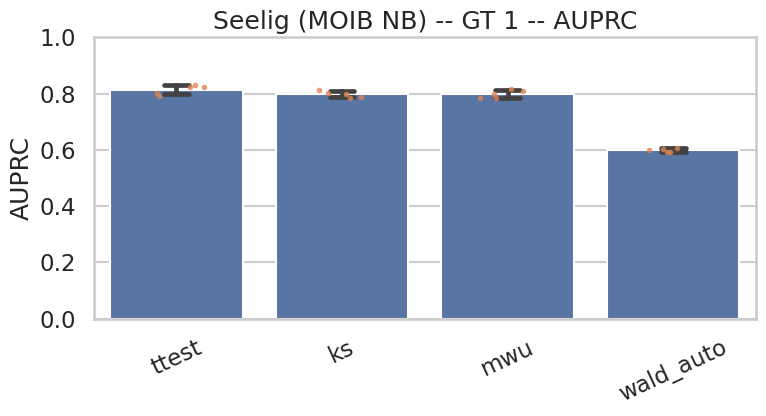

scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:0.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:1.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:2.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:3.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:4.


...

scMPRAforge: INFO: Dropped 5 or 0.2% of tests with NA values for test:ttest, rep:0.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ttest, rep:1.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ttest, rep:2.


scMPRAforge: INFO: Dropped 6 or 0.2% of tests with NA values for test:ttest, rep:3.


scMPRAforge: INFO: Dropped 5 or 0.2% of tests with NA values for test:ttest, rep:4.


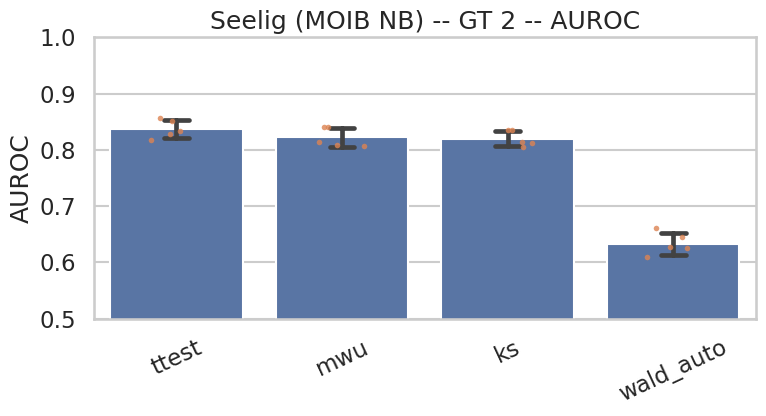

scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:0.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:1.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:2.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:3.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:4.


...

scMPRAforge: INFO: Dropped 5 or 0.2% of tests with NA values for test:ttest, rep:0.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ttest, rep:1.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ttest, rep:2.


scMPRAforge: INFO: Dropped 6 or 0.2% of tests with NA values for test:ttest, rep:3.


scMPRAforge: INFO: Dropped 5 or 0.2% of tests with NA values for test:ttest, rep:4.


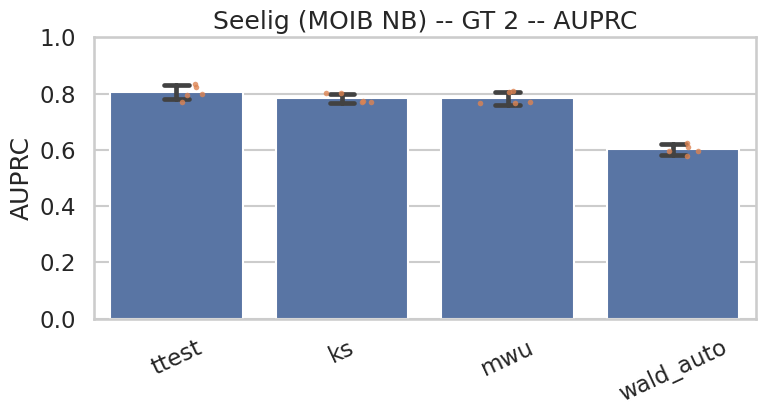

scMPRAforge: INFO: Dropped 3 or 0.1% of tests with NA values for test:ks, rep:0.


scMPRAforge: INFO: Dropped 3 or 0.1% of tests with NA values for test:ks, rep:1.


scMPRAforge: INFO: Dropped 3 or 0.1% of tests with NA values for test:ks, rep:2.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:3.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:4.


...

scMPRAforge: INFO: Dropped 3 or 0.1% of tests with NA values for test:ttest, rep:0.


scMPRAforge: INFO: Dropped 3 or 0.1% of tests with NA values for test:ttest, rep:1.


scMPRAforge: INFO: Dropped 3 or 0.1% of tests with NA values for test:ttest, rep:2.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ttest, rep:3.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ttest, rep:4.


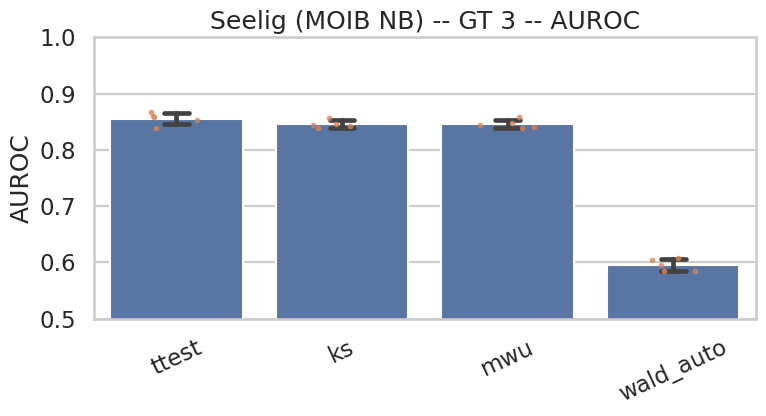

scMPRAforge: INFO: Dropped 3 or 0.1% of tests with NA values for test:ks, rep:0.


scMPRAforge: INFO: Dropped 3 or 0.1% of tests with NA values for test:ks, rep:1.


scMPRAforge: INFO: Dropped 3 or 0.1% of tests with NA values for test:ks, rep:2.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:3.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:4.


...

scMPRAforge: INFO: Dropped 3 or 0.1% of tests with NA values for test:ttest, rep:0.


scMPRAforge: INFO: Dropped 3 or 0.1% of tests with NA values for test:ttest, rep:1.


scMPRAforge: INFO: Dropped 3 or 0.1% of tests with NA values for test:ttest, rep:2.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ttest, rep:3.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ttest, rep:4.


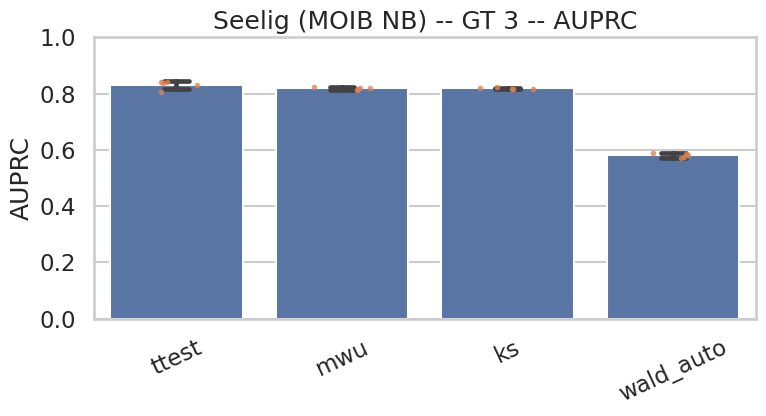

scMPRAforge: INFO: Dropped 5 or 0.2% of tests with NA values for test:ks, rep:0.


scMPRAforge: INFO: Dropped 5 or 0.2% of tests with NA values for test:ks, rep:1.


scMPRAforge: INFO: Dropped 6 or 0.2% of tests with NA values for test:ks, rep:2.


scMPRAforge: INFO: Dropped 6 or 0.2% of tests with NA values for test:ks, rep:3.


scMPRAforge: INFO: Dropped 6 or 0.2% of tests with NA values for test:ks, rep:4.


...

scMPRAforge: INFO: Dropped 5 or 0.2% of tests with NA values for test:ttest, rep:0.


scMPRAforge: INFO: Dropped 5 or 0.2% of tests with NA values for test:ttest, rep:1.


scMPRAforge: INFO: Dropped 7 or 0.3% of tests with NA values for test:ttest, rep:2.


scMPRAforge: INFO: Dropped 6 or 0.2% of tests with NA values for test:ttest, rep:3.


scMPRAforge: INFO: Dropped 7 or 0.3% of tests with NA values for test:ttest, rep:4.


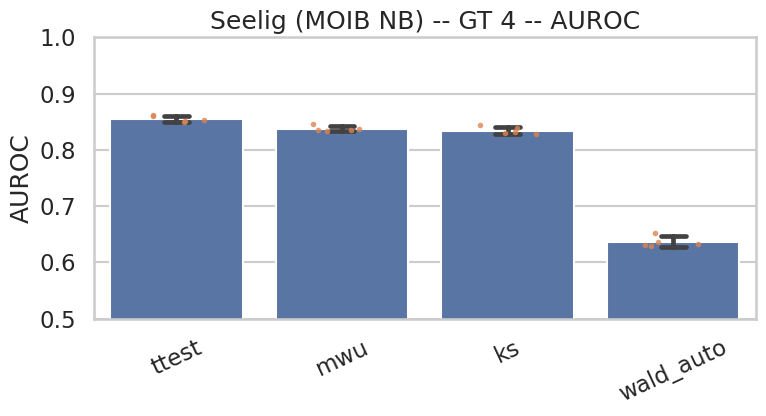

scMPRAforge: INFO: Dropped 5 or 0.2% of tests with NA values for test:ks, rep:0.


scMPRAforge: INFO: Dropped 5 or 0.2% of tests with NA values for test:ks, rep:1.


scMPRAforge: INFO: Dropped 6 or 0.2% of tests with NA values for test:ks, rep:2.


scMPRAforge: INFO: Dropped 6 or 0.2% of tests with NA values for test:ks, rep:3.


scMPRAforge: INFO: Dropped 6 or 0.2% of tests with NA values for test:ks, rep:4.


...

scMPRAforge: INFO: Dropped 5 or 0.2% of tests with NA values for test:ttest, rep:0.


scMPRAforge: INFO: Dropped 5 or 0.2% of tests with NA values for test:ttest, rep:1.


scMPRAforge: INFO: Dropped 7 or 0.3% of tests with NA values for test:ttest, rep:2.


scMPRAforge: INFO: Dropped 6 or 0.2% of tests with NA values for test:ttest, rep:3.


scMPRAforge: INFO: Dropped 7 or 0.3% of tests with NA values for test:ttest, rep:4.


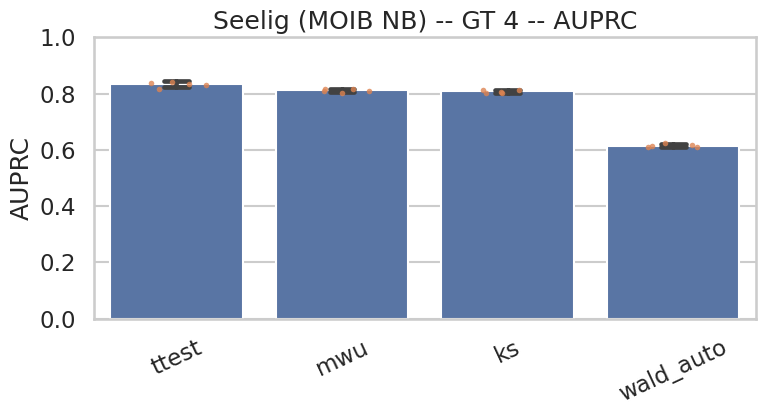

In [7]:
for label, gt_sims in sims.items():
    print(f"\n{'='*60}")
    print(f"{label} -- Performance barcharts")
    print(f"{'='*60}")
    for gt_idx, sim in enumerate(gt_sims):
        for metric in ["auroc", "auprc"]:
            try:
                sim.performance_barchart(HYPOTHESIS_SET, metric)
                plt.title(f"{label} -- GT {gt_idx} -- {metric.upper()}")
                plt.tight_layout()
                plt.show()
            except Exception as e:
                print(f"  GT {gt_idx} {metric}: {e}")

## Cross-dataset comparison boxplots

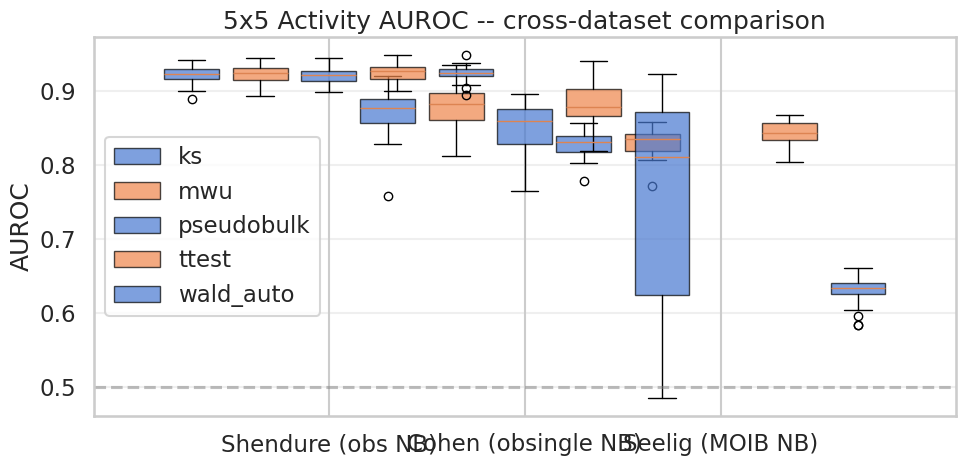

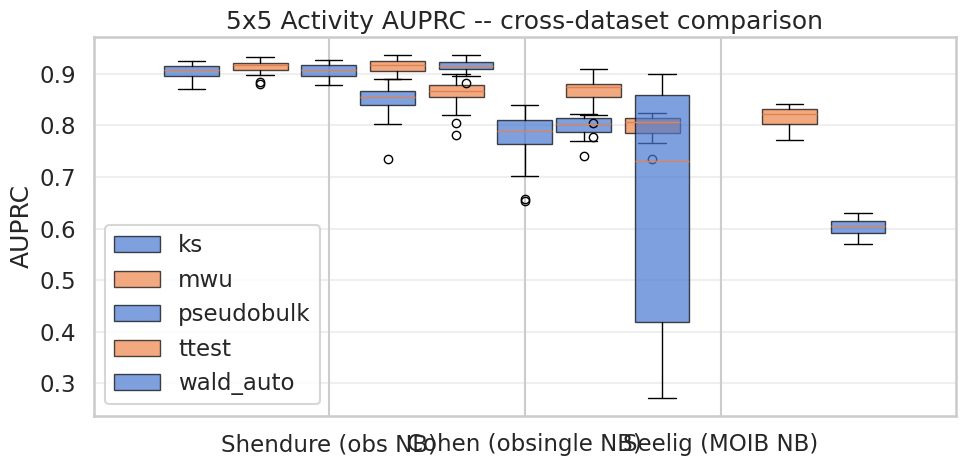

In [8]:
if all_summaries:
    combined = pd.concat(
        [df.assign(dataset=label) for label, df in all_summaries.items()],
        ignore_index=True
    )

    for metric in ["auroc", "auprc"]:
        fig, ax = plt.subplots(figsize=(10, 5))
        datasets = list(all_summaries.keys())
        tests = sorted(combined["test"].unique())
        n_tests = len(tests)
        width = 0.35
        x = range(len(datasets))

        for i, test in enumerate(tests):
            offsets = [xi + (i - n_tests/2 + 0.5) * width for xi in x]
            vals = []
            for ds in datasets:
                sub = combined[(combined["dataset"] == ds) & (combined["test"] == test)]
                vals.append(sub[metric].values)
            bp = ax.boxplot(vals, positions=offsets, widths=width * 0.8,
                           patch_artist=True,
                           boxprops=dict(facecolor=["#4878d0", "#ee854a"][i % 2], alpha=0.7))
            # Label only the first box of each test
            bp["boxes"][0].set_label(test)

        ax.set_xticks(list(x))
        ax.set_xticklabels(datasets)
        ax.set_ylabel(metric.upper())
        ax.set_title(f"5x5 Activity {metric.upper()} -- cross-dataset comparison")
        ax.legend()
        ax.grid(True, alpha=0.3, axis="y")
        if metric == "auroc":
            ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5)
        fig.tight_layout()
        plt.show()

## Paper figures: median GT draw, median replicate (SVG export)

For each dataset, select the GT draw whose mean AUROC (across tests and reps)
is closest to the overall median. Export PRC curves, ROC curves, and
AUROC/AUPRC bar plots as SVGs.

Shendure (obs NB): median GT draw = 0 (mean AUROC=0.925, overall median=0.925, range=0.915-0.927)
Cohen (obsingle NB): median GT draw = 3 (mean AUROC=0.839, overall median=0.839, range=0.836-0.877)
Seelig (MOIB NB): median GT draw = 1 (mean AUROC=0.782, overall median=0.782, range=0.776-0.791)


scMPRAforge: INFO: Dropped 16 or 0.8% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 10 or 0.5% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 10 or 0.5% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 18 or 0.9% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 6 or 0.3% of tests with NA values for test:wald_auto, rep:4.


Called positive: 305 / 2060 (14.8058%)
Called positive: 565 / 2060 (27.4272%)
Called positive: 576 / 2060 (27.9612%)
Called positive: 580 / 2060 (28.1553%)
Called positive: 542 / 2044 (26.5166%)
  Saved output/paper_figs/shendure_median_prc.svg


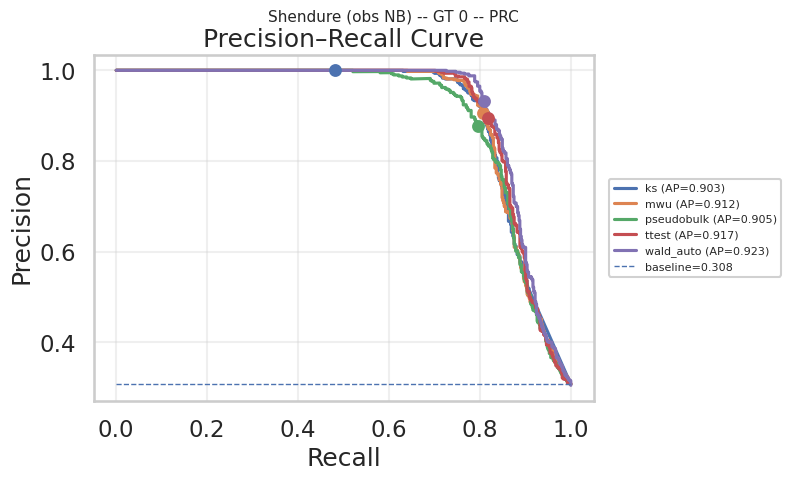

scMPRAforge: INFO: Dropped 16 or 0.8% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 10 or 0.5% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 10 or 0.5% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 18 or 0.9% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 6 or 0.3% of tests with NA values for test:wald_auto, rep:4.


Called positive: 305 / 2060 (14.8058%)
Called positive: 565 / 2060 (27.4272%)
Called positive: 576 / 2060 (27.9612%)
Called positive: 580 / 2060 (28.1553%)
Called positive: 542 / 2044 (26.5166%)
  Saved output/paper_figs/shendure_median_roc.svg


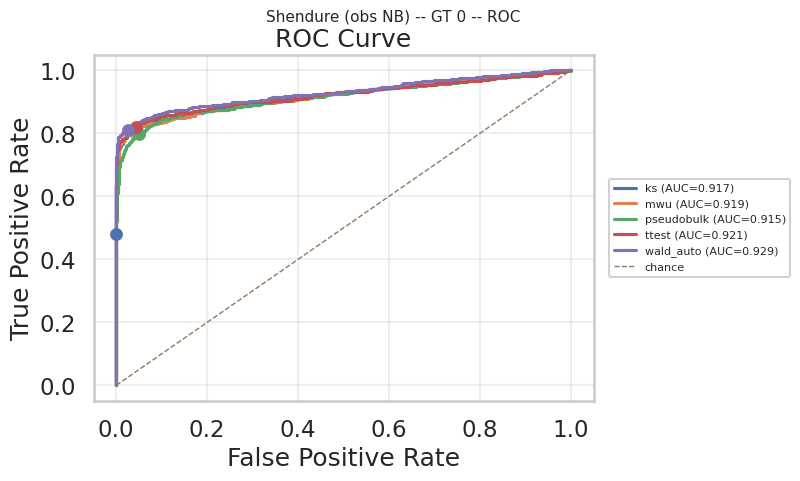

scMPRAforge: INFO: Dropped 2 or 0.4% of tests with NA values for test:pseudobulk, rep:3.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:pseudobulk, rep:4.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:ttest, rep:4.


scMPRAforge: INFO: Dropped 2 or 0.4% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 2 or 0.4% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:wald_auto, rep:4.


Called positive: 84 / 459 (18.3007%)
Called positive: 106 / 459 (23.0937%)
Called positive: 65 / 457 (14.2232%)
Called positive: 106 / 459 (23.0937%)
Called positive: 159 / 457 (34.7921%)
  Saved output/paper_figs/cohen_median_prc.svg


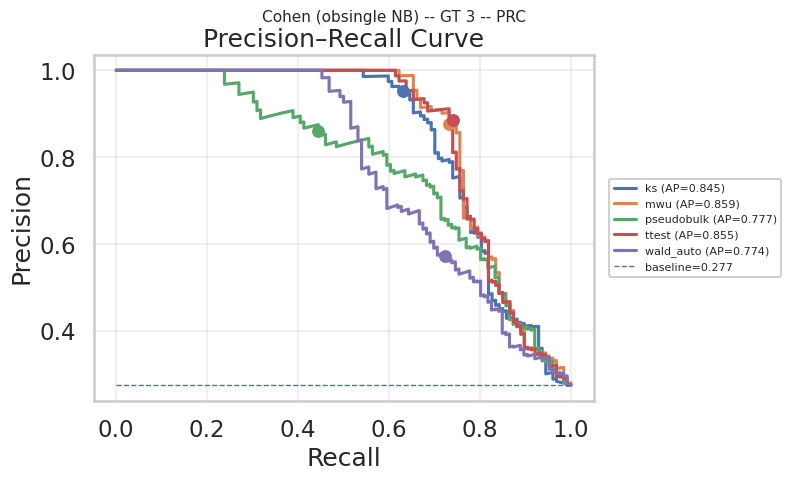

scMPRAforge: INFO: Dropped 2 or 0.4% of tests with NA values for test:pseudobulk, rep:3.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:pseudobulk, rep:4.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:ttest, rep:4.


scMPRAforge: INFO: Dropped 2 or 0.4% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 2 or 0.4% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:wald_auto, rep:4.


Called positive: 84 / 459 (18.3007%)
Called positive: 106 / 459 (23.0937%)
Called positive: 65 / 457 (14.2232%)
Called positive: 106 / 459 (23.0937%)
Called positive: 159 / 457 (34.7921%)
  Saved output/paper_figs/cohen_median_roc.svg


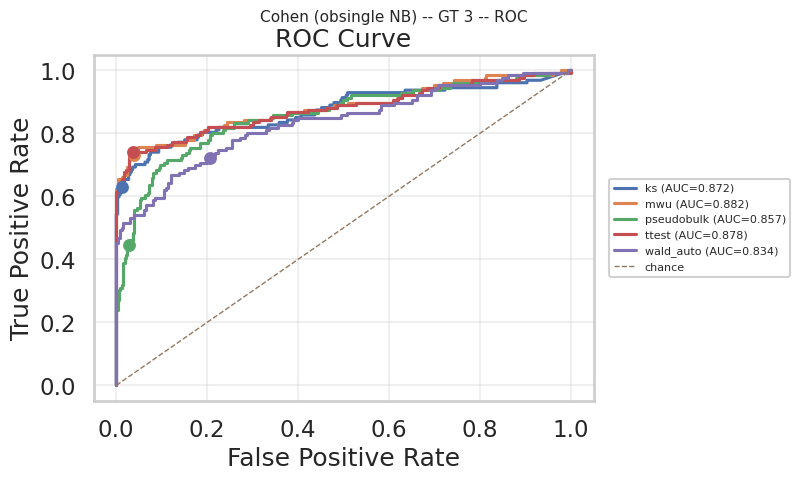

scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:0.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:1.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:2.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:3.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:4.


...

scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ttest, rep:1.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ttest, rep:2.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ttest, rep:3.


scMPRAforge: INFO: Dropped 5 or 0.2% of tests with NA values for test:ttest, rep:4.


Called positive: 378 / 2682 (14.0940%)
Called positive: 499 / 2682 (18.6055%)
Called positive: 621 / 2681 (23.1630%)
Called positive: 2452 / 2686 (91.2882%)
  Saved output/paper_figs/seelig_median_prc.svg


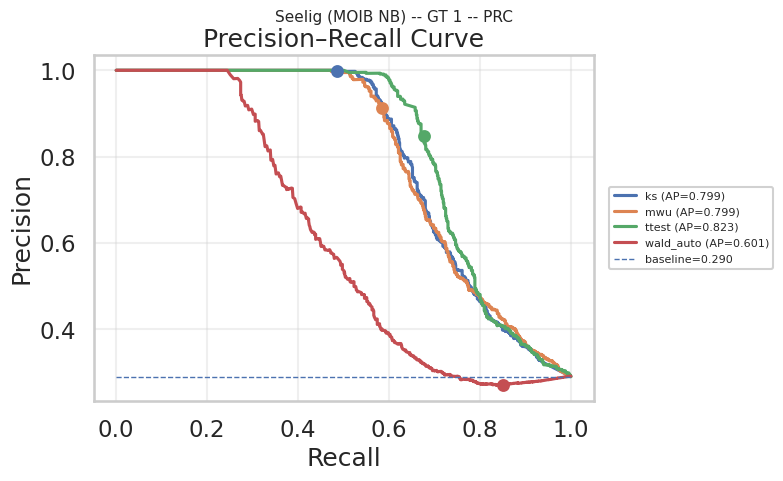

scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:0.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:1.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:2.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:3.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:4.


...

scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ttest, rep:1.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ttest, rep:2.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ttest, rep:3.


scMPRAforge: INFO: Dropped 5 or 0.2% of tests with NA values for test:ttest, rep:4.


Called positive: 378 / 2682 (14.0940%)
Called positive: 499 / 2682 (18.6055%)
Called positive: 621 / 2681 (23.1630%)
Called positive: 2469 / 2686 (91.9211%)
  Saved output/paper_figs/seelig_median_roc.svg


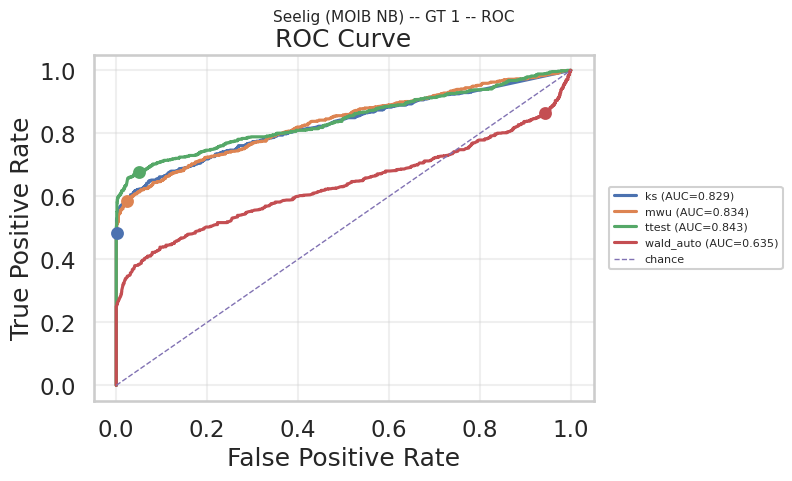

Saved output/paper_figs/cross_dataset_auroc.svg


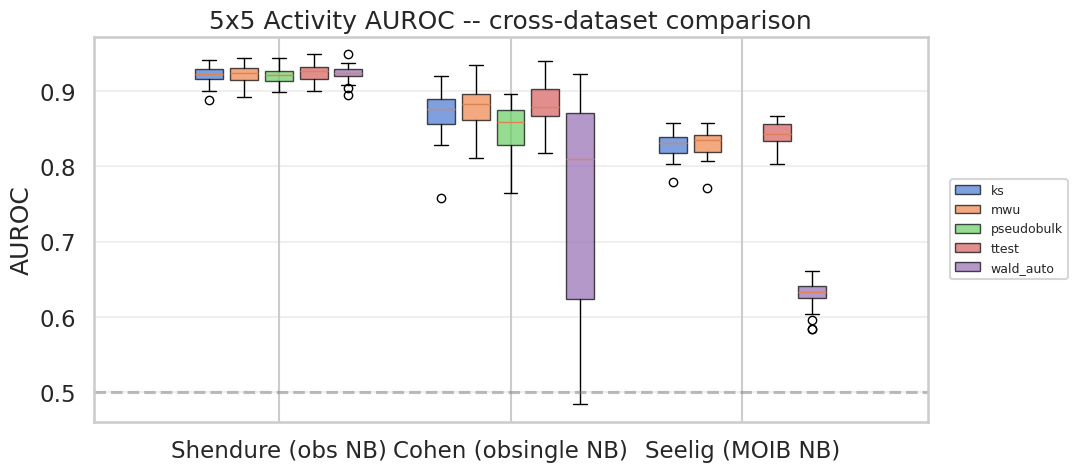

Saved output/paper_figs/cross_dataset_auprc.svg


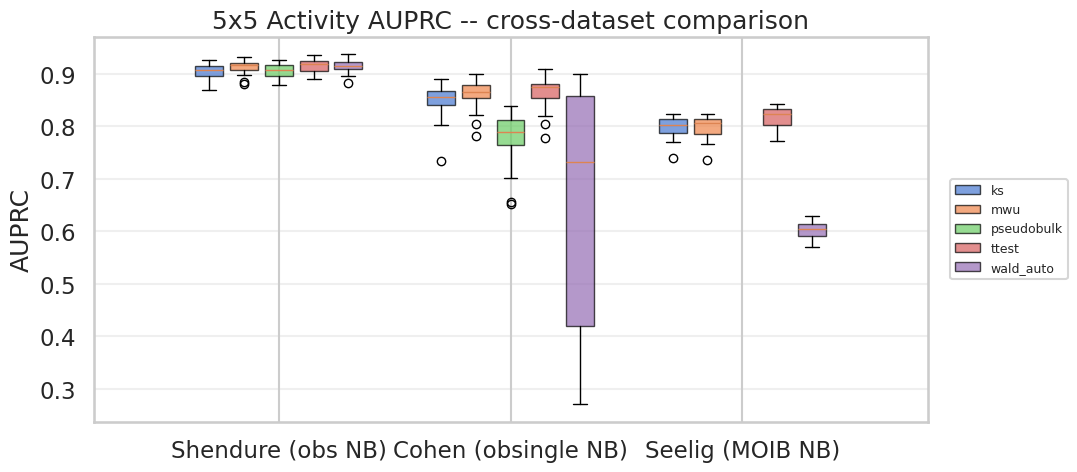

scMPRAforge: INFO: Dropped 16 or 0.8% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 10 or 0.5% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 10 or 0.5% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 18 or 0.9% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 6 or 0.3% of tests with NA values for test:wald_auto, rep:4.


  Saved output/paper_figs/shendure_median_gt_auroc_bar.svg


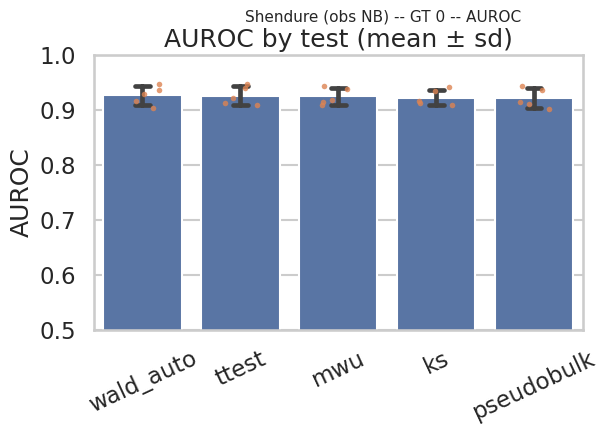

scMPRAforge: INFO: Dropped 16 or 0.8% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 10 or 0.5% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 10 or 0.5% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 18 or 0.9% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 6 or 0.3% of tests with NA values for test:wald_auto, rep:4.


  Saved output/paper_figs/shendure_median_gt_auprc_bar.svg


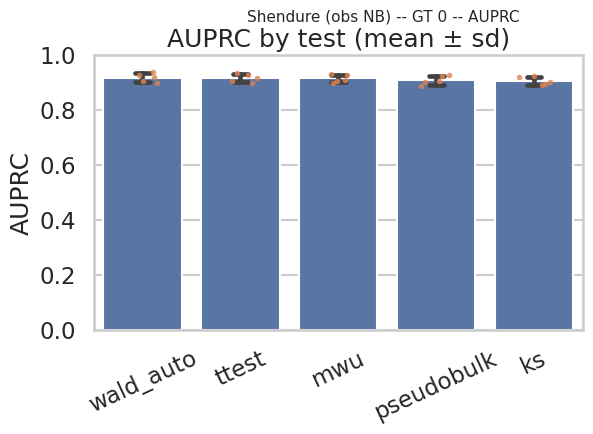

scMPRAforge: INFO: Dropped 2 or 0.4% of tests with NA values for test:pseudobulk, rep:3.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:pseudobulk, rep:4.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:ttest, rep:4.


scMPRAforge: INFO: Dropped 2 or 0.4% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 2 or 0.4% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:wald_auto, rep:4.


  Saved output/paper_figs/cohen_median_gt_auroc_bar.svg


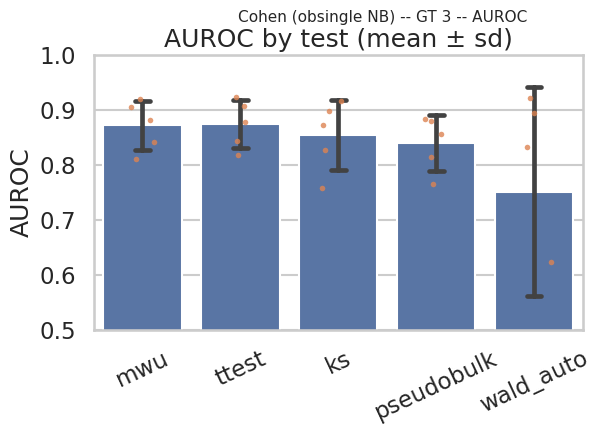

scMPRAforge: INFO: Dropped 2 or 0.4% of tests with NA values for test:pseudobulk, rep:3.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:pseudobulk, rep:4.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:ttest, rep:4.


scMPRAforge: INFO: Dropped 2 or 0.4% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 2 or 0.4% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:wald_auto, rep:4.


  Saved output/paper_figs/cohen_median_gt_auprc_bar.svg


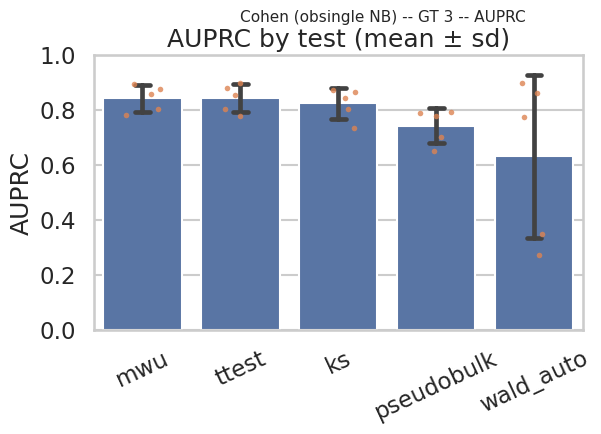

scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:0.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:1.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:2.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:3.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:4.


...

scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ttest, rep:1.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ttest, rep:2.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ttest, rep:3.


scMPRAforge: INFO: Dropped 5 or 0.2% of tests with NA values for test:ttest, rep:4.


  Saved output/paper_figs/seelig_median_gt_auroc_bar.svg


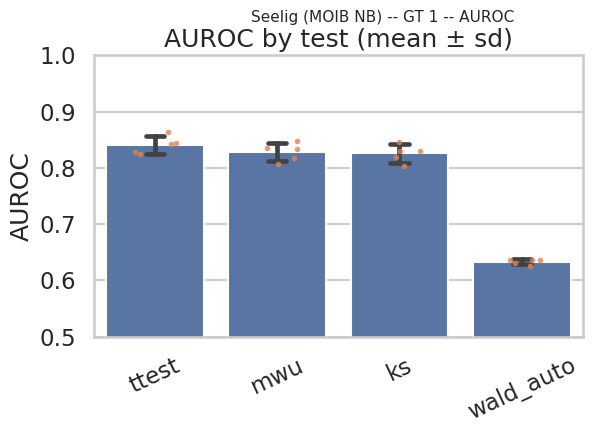

scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:0.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:1.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:2.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:3.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ks, rep:4.


...

scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ttest, rep:1.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ttest, rep:2.


scMPRAforge: INFO: Dropped 4 or 0.1% of tests with NA values for test:ttest, rep:3.


scMPRAforge: INFO: Dropped 5 or 0.2% of tests with NA values for test:ttest, rep:4.


  Saved output/paper_figs/seelig_median_gt_auprc_bar.svg


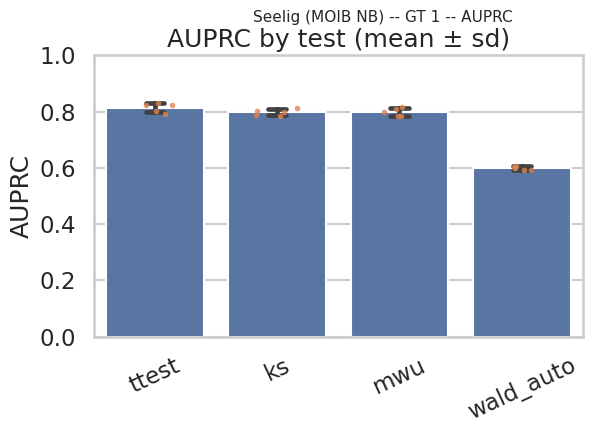


All SVGs saved to /nfs/roberts/project/pi_skr2/mcn26/tabula-rasa/analyses/simulation/activity_prc/output/paper_figs


In [9]:
from pathlib import Path
OUT_DIR = Path("output/paper_figs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Pick median GT draw per dataset
median_gt = {}
for label, df in all_summaries.items():
    gt_means = df.groupby("gt_draw")["auroc"].mean()
    overall_median = gt_means.median()
    best_gt = (gt_means - overall_median).abs().idxmin()
    median_gt[label] = int(best_gt)
    print(f"{label}: median GT draw = {best_gt} "
          f"(mean AUROC={gt_means[best_gt]:.3f}, "
          f"overall median={overall_median:.3f}, "
          f"range={gt_means.min():.3f}-{gt_means.max():.3f})")

def legend_outside(fig):
    for ax in fig.axes:
        leg = ax.get_legend()
        if leg is not None:
            ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5),
                      fontsize=8, framealpha=0.9)
    fig.subplots_adjust(right=0.75)

# --- Per-dataset PRC and ROC SVGs ---
for label, gt_sims in sims.items():
    gt_idx = median_gt.get(label, 0)
    sim = gt_sims[gt_idx]
    slug = label.split("(")[0].strip().lower()

    for kind in ["PRC", "ROC"]:
        sim.median_performance_curve(HYPOTHESIS_SET, kind, include_alpha=True)
        fig = plt.gcf()
        fig.set_size_inches(8, 4.5)
        fig.suptitle(f"{label} -- GT {gt_idx} -- {kind}", fontsize=11)
        legend_outside(fig)
        outpath = OUT_DIR / f"{slug}_median_{kind.lower()}.svg"
        fig.savefig(outpath, format="svg", bbox_inches="tight")
        print(f"  Saved {outpath}")
        plt.show()

# --- Cross-dataset AUROC/AUPRC boxplot SVGs ---
if all_summaries:
    combined = pd.concat(
        [df.assign(dataset=label) for label, df in all_summaries.items()],
        ignore_index=True
    )
    datasets = list(all_summaries.keys())
    tests = sorted(combined["test"].unique())
    n_tests = len(tests)
    width = 0.15

    colors = ["#4878d0", "#ee854a", "#6acc64", "#d65f5f", "#956cb4"]

    for metric in ["auroc", "auprc"]:
        fig, ax = plt.subplots(figsize=(12, 5))
        x = range(len(datasets))
        for i, test in enumerate(tests):
            offsets = [xi + (i - n_tests/2 + 0.5) * width for xi in x]
            vals = []
            for ds in datasets:
                sub = combined[(combined["dataset"] == ds) & (combined["test"] == test)]
                vals.append(sub[metric].values)
            bp = ax.boxplot(vals, positions=offsets, widths=width * 0.8,
                           patch_artist=True,
                           boxprops=dict(facecolor=colors[i % len(colors)], alpha=0.7))
            bp["boxes"][0].set_label(test)
        ax.set_xticks(list(x))
        ax.set_xticklabels(datasets)
        ax.set_ylabel(metric.upper())
        ax.set_title(f"5x5 Activity {metric.upper()} -- cross-dataset comparison")
        ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9)
        ax.grid(True, alpha=0.3, axis="y")
        if metric == "auroc":
            ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5)
        fig.subplots_adjust(right=0.82)
        outpath = OUT_DIR / f"cross_dataset_{metric}.svg"
        fig.savefig(outpath, format="svg", bbox_inches="tight")
        print(f"Saved {outpath}")
        plt.show()

# --- Per-dataset AUROC/AUPRC barcharts (median GT draw) ---
for label, gt_sims in sims.items():
    gt_idx = median_gt.get(label, 0)
    sim = gt_sims[gt_idx]
    slug = label.split("(")[0].strip().lower()

    for metric in ["auroc", "auprc"]:
        sim.performance_barchart(HYPOTHESIS_SET, metric)
        fig = plt.gcf()
        fig.set_size_inches(8, 4.5)
        fig.suptitle(f"{label} -- GT {gt_idx} -- {metric.upper()}", fontsize=11)
        legend_outside(fig)
        outpath = OUT_DIR / f"{slug}_median_gt_{metric}_bar.svg"
        fig.savefig(outpath, format="svg", bbox_inches="tight")
        print(f"  Saved {outpath}")
        plt.show()

print("\nAll SVGs saved to", OUT_DIR.resolve())
